# 09 · Does the "€100 → Gold tier" perk retain people? — RDD (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Customers who cross **€100** annual spend get **Gold** status and its perks.
Gold members retain better — but of course they do, they're big spenders. Does the *perk itself* boost
retention, or are we just seeing that big spenders would retain anyway? And where should we set the
threshold?

### The idea: a sharp rule creates a natural experiment

**Regression discontinuity (RDD)** exploits the fact that Gold status is assigned by a **sharp rule** on a
**running variable** (annual spend): below €100 you're out, at €100-or-above you're in. Now compare a
customer at €99.50 with one at €100.50. On *retention potential* they are essentially identical — nobody
is meaningfully more loyal for having spent one euro more. The *only* thing that differs between them is
that one got the perk and one didn't. So **any jump in retention exactly at €100** must be caused by the
perk, not by the underlying "big spenders retain more" trend (which is smooth through the cutoff). RDD
reads off the size of that jump.

### What it can and can't tell you

- It estimates a **Local Average Treatment Effect (LATE) at the cutoff** — the perk's effect *for customers right at the €100 margin*. *Local* means local-to-the-cutoff: an average effect that holds only for that slice of customers, as opposed to an **Average Treatment Effect (ATE)** over everyone. It says nothing
  about your €500 whales; don't extrapolate the jump to them. (Step 3 makes 'local' precise and contrasts it with the *fuzzy* design, where crossing €100 only nudges the *probability* of Gold rather than flipping it.)
- It's only valid if customers can't **manipulate** their spend to just clear €100 (that would make the
  people just above and just below systematically different). We test this with a **simplified McCrary-style** density check (a symmetric-window binomial test for a suspicious
  pile-up of customers just above the cutoff; the full McCrary 2008 test fits a local-linear density with a Wald SE).
- A headline RD number is only as good as its **robustness checks**: does the jump survive different
  **bandwidths** (how wide a window around €100 we use), **placebo cutoffs** (fake thresholds should show
  no jump), and **polynomial order** (linear vs curved fits)? We run all of them.

> **On real data.** RDD fits anywhere a **threshold rule** assigns a treatment: loyalty tiers, credit-score
> cutoffs for an offer, "spend €X for free shipping," scholarship/eligibility scores. You need the running
> variable, the cutoff, and the outcome — all of which live in your CRM.

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 29; CUTOFF = 100.0; TRUE = 0.14

## 2 · Simulate a ground truth

Retention rises smoothly with annual spend (big spenders retain more anyway) — **plus** a true
**+14pp jump** exactly at €100 from the Gold perk. The smooth part is the confounder; the jump is
the causal effect. Spend is concentrated around the cutoff so both sides are well-populated.

**The data-generating model** — exactly what `dgp.rdd_perk` implements (defaults & seed in
`src/cmp/dgp.py`). $n = 2000$ customers, cutoff $c = 100$:

$$
S \sim \mathcal N(100,\, 40^{2}) \;\text{(clipped below at 1)}, \qquad
D = \mathbf 1[S \ge 100],
$$
$$
p(S) = \operatorname{clip}\Big(\underbrace{0.45 + 0.0015\,(S - 100)}_{\text{smooth baseline}}
  \;+\; \underbrace{0.14\, D}_{\text{the jump}},\; 0.02,\; 0.98\Big),
\qquad Y = \text{retained} \sim \text{Bernoulli}\big(p(S)\big).
$$

The smooth term $0.0015\,(S-100)$ is "big spenders retain more anyway" — the trend that fools the
naive Gold-vs-non-Gold comparison but passes *continuously* through the cutoff (it is deliberately
**linear**, so a local-linear fit is unbiased and the robustness section can vary bandwidth and
polynomial order against a clean benchmark). The $0.14\,D$ term is the perk's true +14pp causal
jump. Centering spend on the cutoff ($S \sim \mathcal N(100, 40^{2})$) keeps both sides of the
threshold densely populated.


In [2]:
df, true_jump = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=SEED)
df["treated"] = df["treated"].astype(int)
print(f"TRUE perk effect = +{true_jump:.0%} retention at €{CUTOFF:.0f}  ·  {(df.spend>=CUTOFF).mean():.0%} are Gold")
df.head()

TRUE perk effect = +14% retention at €100  ·  50% are Gold


,spend,treated,retention
0,84.325206,0,1.0
1,101.996816,1,0.0
2,93.392393,0,1.0
3,93.281224,0,0.0
4,102.504635,1,0.0


### 2b · First, watch the naive comparison fail

The obvious analysis — the one every loyalty dashboard already shows — is *average retention of Gold
members vs everyone else*. Before fixing it, let's compute it and see exactly **how** wrong it is.
Because we wrote the DGP, we can decompose the naive gap in closed form. Write $\Delta = S - c$
(spend centered on the cutoff) and $D = \mathbf 1[\Delta \ge 0]$; then

$$
\underbrace{\mathbb E[Y \mid D{=}1] - \mathbb E[Y \mid D{=}0]}_{\text{naive Gold-vs-rest gap}}
\;=\; \underbrace{0.14}_{\text{true jump}}
\;+\; \underbrace{0.0015\,\big(\mathbb E[\Delta \mid \Delta \ge 0]
 - \mathbb E[\Delta \mid \Delta < 0]\big)}_{\text{selection: Gold members are big spenders}}.
$$

With $\Delta \sim \mathcal N(0, 40^{2})$, each one-sided mean is $40\sqrt{2/\pi} \approx 31.9$
in absolute value (the average distance from the mean on one side of a mean-zero Normal is $\sigma\sqrt{2/\pi}$), so the selection term is $0.0015 \times 2 \times 31.9 \approx +9.6$pp (spend
and probability clipping make this slightly approximate). Roughly **+10pp of pure selection** stacked
on top of the +14pp causal jump — the naive gap credits the perk with the whole "big spenders retain
anyway" trend. That +10pp is exactly what RDD will subtract off by comparing customers only *at the
margin*, where the selection term vanishes.

In [3]:
naive = df.loc[df.treated == 1, "retention"].mean() - df.loc[df.treated == 0, "retention"].mean()
pred_selection = 0.0015 * 2 * 40 * np.sqrt(2 / np.pi)     # closed-form selection term (pre-clipping)
print(f"Naive Gold-vs-rest gap: {naive:+.1%}   =   true causal jump +{TRUE:.0%}   +   selection bias {naive - TRUE:+.1%}")
print(f"(closed-form prediction of the selection term: +{pred_selection:.1%}; the small remainder is clipping + sampling noise)")
print("The naive dashboard number nearly doubles the perk's true effect — pure 'big spenders retain anyway' selection.")

Naive Gold-vs-rest gap: +23.9%   =   true causal jump +14%   +   selection bias +9.9%
(closed-form prediction of the selection term: +9.6%; the small remainder is clipping + sampling noise)
The naive dashboard number nearly doubles the perk's true effect — pure 'big spenders retain anyway' selection.


## 3 · Identify — a jump at the cutoff is causal (and its validity conditions)

**Potential outcomes.** Let $Y_i(1)$ and $Y_i(0)$ be customer $i$'s retention *with* and *without*
the perk, $S_i$ the running variable (annual spend), and $D_i = \mathbf 1[S_i \ge c]$ the sharp
assignment rule at the cutoff $c$ (here €100). The **estimand** — the exact quantity we're trying to pin down — is the perk's effect **for
customers at the margin**:

$$
\tau_{RD} \;=\; \mathbb E\big[Y(1) - Y(0) \,\big|\, S = c\big].
$$

**Assumption (continuity).** The conditional means $x \mapsto \mathbb E[Y(d) \mid S = x]$ are
*continuous at* $c$ for $d \in \{0, 1\}$. In words: **nothing else that drives retention jumps at
€100** — loyalty, tenure, customer quality all pass smoothly through the threshold; the perk is the
only thing that switches. Then the observed jump identifies $\tau_{RD}$ in two steps ($x \downarrow c$ means spend approaching €100 from *above*, $x \uparrow c$ from *below*):

$$
\begin{aligned}
&\lim_{x \downarrow c} \mathbb E[Y \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y \mid S{=}x] \\
&\quad=\; \lim_{x \downarrow c} \mathbb E[Y(1) \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y(0) \mid S{=}x] \\
&\quad=\; \mathbb E[Y(1) \mid S{=}c] - \mathbb E[Y(0) \mid S{=}c] \;=\; \tau_{RD}.
\end{aligned}
$$

First equality: just above the cutoff every customer is treated, so the observed $Y$ *is* $Y(1)$;
just below, it *is* $Y(0)$. Second equality: continuity lets each one-sided limit converge to its
value *at* $c$. So the observable jump in average retention at €100 **equals** the causal effect at
€100 — we don't need to *assume away* hidden confounders or model who selects into treatment (the machinery of the earlier notebooks); the sharp rule plus continuity does all the work.
The price is *locality*: this is a **LATE at the cutoff** — an ATE exactly at €100, silent about
your €500 whales.

**Manipulation is a continuity violation — and it leaves fingerprints.** If customers (or account
managers) sort across the threshold — nudging a €97 basket to €101 — the *kind* of customer just
above €100 differs from the kind just below, so $\mathbb E[Y(d) \mid S = x]$ becomes
*discontinuous* at $c$ and the derivation collapses. Continuity itself is untestable (it's about
potential outcomes), but sorting leaves observable fingerprints, which gives us two **testable
implications**: the *density* of spend should be smooth at €100 (the McCrary check, 3b), and
*pre-determined covariates* should be smooth at €100 (the balance check, 3c). They can't prove
continuity; they can catch it failing.

**Sharp vs fuzzy — where this design sits.** Here the rule is *sharp*: $P(D{=}1 \mid S{=}x)$ jumps
from 0 to 1 at €100. When the rule is leaky (grandfathered members, manual overrides), crossing the
threshold only *raises the probability* of Gold, and the estimand becomes the **fuzzy-RD** ratio

$$
\tau_{\text{fuzzy}} \;=\;
\frac{\lim_{x \downarrow c} \mathbb E[Y \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[Y \mid S{=}x]}
     {\lim_{x \downarrow c} \mathbb E[D \mid S{=}x] - \lim_{x \uparrow c} \mathbb E[D \mid S{=}x]}
$$

— the outcome jump rescaled by the treatment-probability jump. That ratio is exactly a **Wald/IV
estimator** — where an *instrument* is a variable that nudges who gets treated but affects the outcome only *through* that treatment; here "crossed the €100 threshold" is the instrument (full treatment in notebook 11) — and it identifies a
*complier*-LATE at the cutoff: the effect for customers whose Gold status actually flips when they
cross €100. In our sharp design the denominator is 1 and $\tau_{\text{fuzzy}}$ collapses to
$\tau_{RD}$ — which is the precise sense in which "local" here means local-to-the-cutoff, *not*
complier-local. Two things must hold for the sharp analysis, both checked below:

- **No manipulation** of the running variable at the cutoff — the McCrary-style density check (3b)
  plus covariate continuity (3c).
- **The functional form isn't driving the jump** — bandwidth, placebo cutoffs, and polynomial order
  (Step 5).


## 3b · Validity check 1 — McCrary-style density check (manipulation)

If customers game their spend to just clear €100 (or the business nudges them), the *density* of
spend jumps at the cutoff and RD breaks. We compare the density just below vs just above with a symmetric-window binomial test. (This is a
*simplified* version; the full McCrary 2008 test fits a local-linear density on each side with a formal standard error on the density gap.)
This is the first of the two testable implications of continuity derived in Step 3; the second —
pre-determined covariates must not jump — follows in 3c.


density just below 23.7 vs above 24.0, log-ratio +0.01, binomial z +0.15 — no significant sorting across the cutoff (|z| < 2).


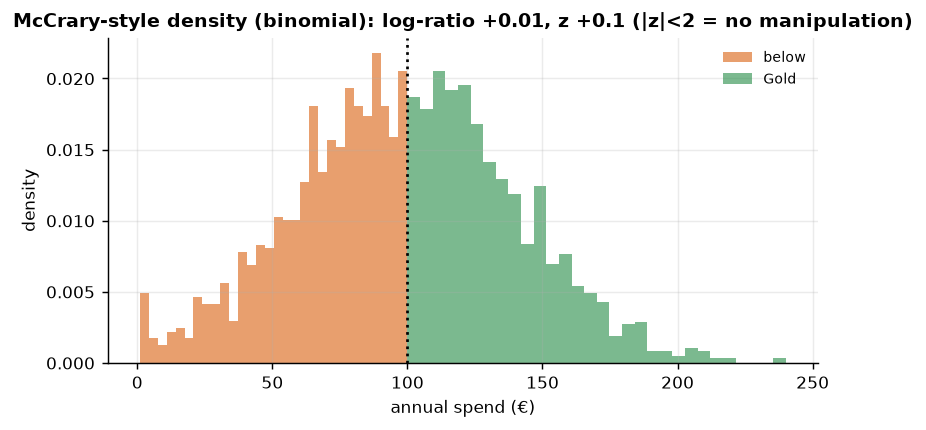

In [4]:
d_below, d_above, log_ratio, z_mcc = est.mccrary_density(df.spend.values, CUTOFF, bandwidth=15)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(df.spend[df.spend < CUTOFF], bins=30, color=plots.ORANGE, alpha=0.6, density=True, label="below")
ax.hist(df.spend[df.spend >= CUTOFF], bins=30, color=plots.GREEN, alpha=0.6, density=True, label="Gold")
ax.axvline(CUTOFF, color="k", ls=":"); ax.set_xlabel("annual spend (€)"); ax.set_ylabel("density")
ax.set_title(f"McCrary-style density (binomial): log-ratio {log_ratio:+.2f}, z {z_mcc:+.1f} (|z|<2 = no manipulation)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"density just below {d_below:.1f} vs above {d_above:.1f}, log-ratio {log_ratio:+.2f}, binomial z {z_mcc:+.2f} — "
      + ("no significant sorting across the cutoff (|z| < 2)." if abs(z_mcc) < 2 else "SIGNIFICANT pile-up — possible manipulation!"))

(The density is smooth through €100 — no suspicious pile-up of customers *just* above the cutoff — so we
have no evidence of manipulation, and the RDD comparison is fair.)

### 3c · Validity check 2 — pre-determined covariates don't jump at the cutoff

Continuity has a **second** testable implication. Anything determined *before* the perk decision —
how long the customer has been with us, how many orders they placed last year — *cannot* be caused
by it. So if we run the very same RD machinery with a **pre-determined covariate as the "outcome"**,
the estimated jump at €100 must be ≈ 0. A real jump in, say, tenure would mean the *people* just
above and just below the threshold are different people — continuity violated — exactly like an
unbalanced covariate in a botched RCT, localized to the cutoff. Together with McCrary this is the
standard falsification *pair* of applied RD (the Lee–Lemieux checklist).

Our simulated CRM has no covariates, so we create two that mirror the real-world pattern: strongly
**correlated with spend** (so they'd fool a naive comparison) but **smooth through €100 by
construction** (nothing in how they're generated knows about the cutoff — the null is true, and the
test should say so). On real CRM data you run this on *every* pre-treatment column you have and
report the whole table, like an RCT balance table.

To run the check — and later the whole Step-5 robustness battery — we need a fast, reusable
**local-linear RD fit**: plain OLS with a standard error on the jump, so every check is judged by a
*t*-statistic rather than an eyeball.

pre-determined covariate tenure_m : jump at €100 = -0.78  (t = -0.68)
pre-determined covariate n_orders : jump at €100 = +0.20  (t = +1.04)
Both |t| < 2 — covariates pass smoothly through the cutoff; the people either side are comparable.


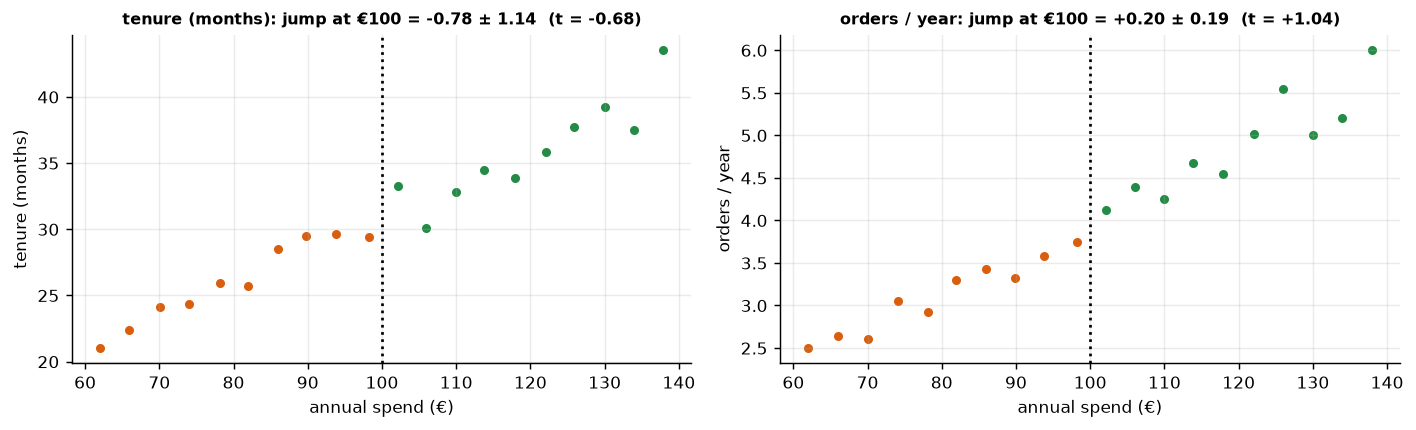

In [5]:
def rd_jump(data, cutoff, bw, order=1, ycol="retention"):
    """Local polynomial RD jump at `cutoff` within ±bw, for any outcome column
    `ycol`. Returns the estimated discontinuity (the coefficient on the 'treated'
    indicator — the jump AT the cutoff, because x is centered here) AND its
    classical OLS standard error, so any jump — real, placebo, or covariate —
    can be judged against zero with a t-stat rather than eyeballed. Reused by
    the covariate check below and the whole Step-5 robustness battery."""
    sub = data[np.abs(data.spend - cutoff) <= bw]
    x = (sub.spend - cutoff).values; tr = (sub.spend >= cutoff).astype(float).values; y = sub[ycol].values
    cols = [np.ones(len(x)), tr, x, x*tr]
    if order == 2: cols += [x**2, x**2*tr]
    D = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(D, y, rcond=None)
    resid = y - D @ beta; n, k = D.shape
    cov = (resid @ resid / max(n - k, 1)) * np.linalg.pinv(D.T @ D)
    return float(beta[1]), float(np.sqrt(max(cov[1, 1], 0.0)))   # (jump, SE of the jump)

# Two PRE-DETERMINED covariates: correlated with spend, smooth through €100 by construction.
# (Generated in-notebook — dgp.rdd_perk stays untouched; other notebooks share it.)
rng_cov = np.random.default_rng(SEED + 2)
df["tenure_m"] = np.clip(6 + 0.25 * df.spend + rng_cov.normal(0, 12, len(df)), 1, None)  # months as customer
df["n_orders"] = rng_cov.poisson(np.clip(df.spend / 25, 0.5, None)).astype(float)        # orders last year

cov_checks = {c: rd_jump(df, CUTOFF, 40, ycol=c) for c in ["tenure_m", "n_orders"]}
band = df[np.abs(df.spend - CUTOFF) <= 40].copy()
band["bin"] = pd.cut(band.spend, np.linspace(CUTOFF - 40, CUTOFF + 40, 21))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, (col, lab) in enumerate([("tenure_m", "tenure (months)"), ("n_orders", "orders / year")]):
    b = band.groupby("bin", observed=True).agg(spend=("spend", "mean"), y=(col, "mean")).dropna()
    below = b.spend < CUTOFF
    ax[k].scatter(b.spend[below], b.y[below], color=plots.ORANGE, s=16)
    ax[k].scatter(b.spend[~below], b.y[~below], color=plots.GREEN, s=16)
    j, se = cov_checks[col]
    ax[k].axvline(CUTOFF, color="k", ls=":"); ax[k].set_xlabel("annual spend (€)"); ax[k].set_ylabel(lab)
    ax[k].set_title(f"{lab}: jump at €100 = {j:+.2f} ± {se:.2f}  (t = {j/se:+.2f})", fontsize=9)
fig.tight_layout()
for col, (j, se) in cov_checks.items():
    print(f"pre-determined covariate {col:9s}: jump at €100 = {j:+.2f}  (t = {j/se:+.2f})")
print("Both |t| < 2 — covariates pass smoothly through the cutoff; the people either side are comparable."
      if all(abs(j/se) < 2 for j, se in cov_checks.values())
      else "A covariate JUMPS at the cutoff — continuity is suspect; investigate before trusting any RD number.")

**How to read it.** Both covariates climb steeply with spend — Gold members *are* longer-tenured,
heavier orderers, which is precisely why the naive comparison in 2b lied — but each trend passes
**smoothly** through €100: the local-linear jump is statistically zero for both (t-stats printed
above). Combined with the clean McCrary density, this is the RD analogue of an RCT balance check — the **local-randomization** intuition in action:
in a narrow window around the cutoff, who ends up just above vs just below is as good as a coin flip, so
near the threshold *who you are* doesn't change — only Gold status does. Had tenure jumped at €100,
no amount of modelling would rescue the design; the fix is to find out *why* (account managers gaming
the tier? a billing process that rounds spend up?) — not a fancier regression.

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst would do here **without** it. The answer
is not a different analysis: it is the *same estimand* — $\tau_{RD} = \mathbb E[Y(1) - Y(0) \mid S = c]$,
the jump at €100 written down in §3 — identified by the *same assumption* (continuity of the
potential-outcome means at the cutoff), estimated with the simplest tool that is still correct. The
causal work lives in the identification argument, not in the machinery, and it is worth seeing that
once, cleanly, before a likelihood, a prior and a sampler arrive and start doing work of their own.

**First, the comparison the design exists to replace.** The loyalty dashboard's number — average
retention of Gold members minus everyone else — is a *difference in means*, and §2b already showed it
lands near +24pp against a planted truth of +14pp. Step 0 re-runs it with an honest **Welch standard
error** (unequal variances across the two groups), because the point of the exercise is not that the
naive number is *noisy*. It is that the naive number is **precise and wrong**: with 2,500 customers
its confidence interval is tight — and, as the print-out shows, it *excludes the truth entirely*. No
amount of extra data fixes that; selection bias does not shrink with $n$. This is why we need the
discontinuity at all.

**The classical RD estimator, naked.** Keep only the customers within a **bandwidth** $h$ of the
cutoff, fit **one straight line on each side**, and read off the gap where they meet. As weighted
least squares, with $\Delta_i = S_i - c$ the centered running variable, $D_i = \mathbf 1[\Delta_i \ge 0]$,
and a **triangular kernel** $K(u) = 1 - |u|$ that gives a customer at €99 more weight than one at €65:

$$
(\hat\alpha,\ \hat\tau,\ \hat\beta_-,\ \hat\beta_+)
\;=\; \arg\min \!\!\sum_{|\Delta_i| \le h} \!\! K\!\Big(\tfrac{\Delta_i}{h}\Big)\,
\Big(Y_i - \alpha - \tau D_i - \beta_-\Delta_i - \beta_+ \Delta_i D_i\Big)^{2},
\qquad \hat\tau_{RD}(h) = \hat\tau .
$$

Because $\Delta$ is centered *at the cutoff*, the coefficient $\hat\tau$ on the treated indicator **is**
the jump at €100 — the difference of the two fitted lines evaluated at $\Delta = 0$ — and nowhere else.
It estimates a LATE **at the threshold** (§3): it says nothing about your €500 whales, and no
standard error can buy that back. That is `cl.rd_local_linear`, and it is what the applied literature
means by "local linear RD".

**The covariance choice: HC1, and not by habit.** Retention is 0/1, so this is a linear probability
model and its residual variance is $p(1-p)$ — a quantity that *moves with the fitted probability by
construction*. The errors are heteroskedastic as a matter of algebra, not as a suspicion, so the
homoskedastic OLS standard error is the wrong one to report. `cl.rd_local_linear` uses **HC1**
(heteroskedasticity-robust) — the cross-section analogue of clustering on a panel (notebook 08) or HAC
on a time series (notebook 10).

**And the choice the classical arm cannot defend: the bandwidth.** $h$ is not estimated by the model;
it is *picked*, and the answer moves with it (narrow = fewer customers, more variance; wide = borrows
non-comparable customers, more bias). Whatever interval comes out is **conditional on $h$** — it prices
sampling noise *given* the window, and prices the window itself at zero. This is exactly the pathology
of notebook 06's classical MMM, whose tight CI on TV's ROAS was conditional on adstock and saturation
parameters fixed by fiat — and, there, missed the truth because of it. So we report the estimate across
a **grid of bandwidths** and let the reader see the width the single interval is not showing them. (The
grid computed here is the one Step 5's bandwidth curve plots; we do it once.)

In [6]:
from cmp import classical as cl

# --- (1) The naive dashboard comparison, with an honest (Welch) interval -----------------
naive_cl = cl.diff_in_means(df.retention.values, df.treated.values,
                            name="Naive Gold-vs-rest gap")

# --- (2) THE classical RD: local linear each side, triangular kernel, HC1, h = ±€40 -------
H = 40.0
rd_cl = cl.rd_local_linear(df, outcome="retention", running="spend",
                           cutoff=CUTOFF, bandwidth=H)

# --- (3) The bandwidth is chosen by fiat, so sweep it (Step 5's curve reuses this) --------
bws = np.arange(15, 61, 5)
bw_scan = [cl.rd_local_linear(df, outcome="retention", running="spend",
                              cutoff=CUTOFF, bandwidth=float(h)) for h in bws]

pp = lambda x: f"{100 * x:+.1f}pp"
print(f"THE NAIVE COMPARISON (what the dashboard shows), n = {naive_cl.n:,}")
print(f"  {pp(naive_cl.estimate)}  [90% CI {pp(naive_cl.ci[0])}, {pp(naive_cl.ci[1])}]"
      f"  ·  SE {100 * naive_cl.se:.1f}pp  ·  {naive_cl.cov}")
covers_naive = naive_cl.ci[0] <= TRUE <= naive_cl.ci[1]
print(f"  vs the planted truth (+{TRUE:.0%}): the truth is "
      f"{'INSIDE' if covers_naive else 'OUTSIDE'} this 90% CI"
      f" — precise, and wrong by {pp(naive_cl.estimate - TRUE)} of pure selection.\n")

print(f"THE CLASSICAL RD (local linear, triangular kernel, HC1, h = ±€{H:.0f}) — the estimand of §3")
print(f"  {rd_cl!r}")
inside = rd_cl.ci[0] <= TRUE <= rd_cl.ci[1]
print(f"  GRADE vs the planted truth (+{TRUE:.0%}): off by {pp(rd_cl.estimate - TRUE)}; "
      f"the truth falls {'INSIDE' if inside else 'OUTSIDE'} the 90% CI.")
print(f"  It threw away {len(df) - rd_cl.n:,} of {len(df):,} customers to buy comparability "
      f"({rd_cl.extra['n_left']:,} below / {rd_cl.extra['n_right']:,} above the cutoff remain).\n")

print("THE BANDWIDTH IS A CHOICE, NOT AN ESTIMATE — the same estimator, ten windows:")
print(f"  {'h (±€)':>7}{'n':>7}{'jump':>8}{'90% CI':>20}{'excl. 0?':>10}{'covers +14pp?':>15}")
for h, r in zip(bws, bw_scan):
    lo, hi = r.ci
    print(f"  {h:>7.0f}{r.n:>7,}{pp(r.estimate):>8}"
          f"{f'[{pp(lo)}, {pp(hi)}]':>20}"
          f"{('yes' if r.significant else 'NO'):>10}"
          f"{('yes' if lo <= TRUE <= hi else 'NO'):>15}")
e_grid = np.array([r.estimate for r in bw_scan])
env_lo = min(r.ci[0] for r in bw_scan); env_hi = max(r.ci[1] for r in bw_scan)
half = (rd_cl.ci[1] - rd_cl.ci[0]) / 2
print(f"  point estimates span {pp(e_grid.min())} … {pp(e_grid.max())} "
      f"(a range of {100 * np.ptp(e_grid):.1f}pp), i.e. {np.ptp(e_grid) / half:.0%} of the reported "
      f"half-width at h = ±€{H:.0f} ({pp(half)}) —")
print(f"  and the significance verdict itself flips: "
      f"{sum(not r.significant for r in bw_scan)} of {len(bw_scan)} windows cannot exclude zero.")
print(f"  Union of the ten intervals: [{pp(env_lo)}, {pp(env_hi)}] — the width the single "
      f"h = ±€{H:.0f} interval is not showing you.\n")

# The Step-5 falsification battery is judged with `rd_jump` (§3c) — the SAME local-linear
# specification with a uniform kernel and a homoskedastic SE. Check the two agree on the jump:
print(f"Consistency with §3c's `rd_jump` helper (uniform kernel, homoskedastic SE), h = ±€{H:.0f}: "
      f"{pp(rd_jump(df, CUTOFF, H)[0])} vs "
      f"{pp(cl.rd_local_linear(df, outcome='retention', running='spend', cutoff=CUTOFF, bandwidth=H, kernel='uniform').estimate)}"
      " — identical estimator, so the placebo/polynomial battery of Step 5 inherits this same read.\n")

print(rd_cl.cannot_say())

THE NAIVE COMPARISON (what the dashboard shows), n = 2,500
  +23.9pp  [90% CI +20.7pp, +27.1pp]  ·  SE 1.9pp  ·  Welch (unequal variances)
  vs the planted truth (+14%): the truth is OUTSIDE this 90% CI — precise, and wrong by +9.9pp of pure selection.

THE CLASSICAL RD (local linear, triangular kernel, HC1, h = ±€40) — the estimand of §3
  RD jump at spend=100: 0.1112  [90% CI 0.02685, 0.1956]  (SE 0.0513, HC1, local linear, triangular kernel, h=40, n=1,706)
  GRADE vs the planted truth (+14%): off by -2.9pp; the truth falls INSIDE the 90% CI.
  It threw away 794 of 2,500 customers to buy comparability (849 below / 857 above the cutoff remain).

THE BANDWIDTH IS A CHOICE, NOT AN ESTIMATE — the same estimator, ten windows:
   h (±€)      n    jump              90% CI  excl. 0?  covers +14pp?
       15    716  +7.7pp   [-5.8pp, +21.2pp]        NO            yes
       20    938  +9.8pp   [-2.1pp, +21.6pp]        NO            yes
       25  1,172 +10.5pp   [-0.1pp, +21.0pp]        NO   

**Read-out — the classical answer, in business terms.** The naive Gold-vs-rest gap and the RD jump
disagree by roughly the selection term §2b predicted in closed form, and only one of them contains the
truth. The dashboard number is the cautionary tale: **a tight interval around the wrong number**, and
the tightness is *why* it is dangerous — it will pass every review, because nothing in a confidence
interval knows about confounding. The RD estimate throws away nearly a third of the customer base (the exact
count is printed above) to buy comparability, comes back with a far wider interval, and is *right* (the planted +14pp sits inside it). Precision you
did not earn is not a virtue.

**But look hard at the bandwidth table, because it is the honest weakness of this arm.** The point
estimate climbs steadily as the window widens, and the *significance verdict itself* depends on the
window: at the narrow bandwidths the 90% CI cannot exclude zero, at the wide ones it comfortably does.
The single interval we report at $h = \pm€40$ prices sampling noise *given* that window — it does not
price the choice of window, which is the one part of this analysis a colleague could most easily
disagree with. That is the same failure mode as notebook 06's classical MMM (a confident CI on ROAS,
conditional on adstock and saturation parameters fixed by hand), and it is a **general property of
plugging in a tuning parameter**: the interval you get back is a conditional interval wearing an
unconditional face.

Two things keep it from being fatal here, and both are worth naming because on your data they may not
hold. First, the ranking of *bias* is benign: our DGP's smooth trend is **linear by construction** (§2),
so a wide window borrows distant customers without inducing curvature bias — on real, curved data the
wide bandwidths would be biased, not merely different. Second, every window's interval covers the
truth, so the conditionality costs us honesty about the width, not the answer. The disciplined
classical practice is to *pick $h$ by a rule you wrote down before seeing the outcome* — the plug-in
optimal bandwidths of Imbens–Kalyanaraman (2012) or Calonico–Cattaneo–Titiunik (`rdrobust`) — and then
show the sweep anyway, as Step 5 does.

Notice what has *not* happened yet: no likelihood was written down, no prior chosen, no sampler run.
Continuity at the cutoff did all the causal work; a weighted least-squares fit did all the estimation.
**This is the honest baseline the Bayesian section must justify itself against** — and §5x holds it to
exactly that.

**The guardrail — what that confidence interval does *not* say** (printed above, in the same words in
every notebook of this cookbook): it is **not** a 90% probability that the perk's true effect lies
inside it. A confidence interval is a property of the *procedure*; this particular interval either
covers +14pp or it does not. The distinction is not pedantry, and §6 is precisely where it bites:
the CMO's question is *"what is the probability the perk clears its €15/member cost?"* — a probability
**about the effect itself**. The classical apparatus has no such quantity in its vocabulary. A
posterior does.

## 4 · Estimate — Bayesian regression discontinuity

Now the estimate itself. We fit a **local linear** regression on each side of the cutoff — a straight line
for the below-€100 customers and another for the Gold customers — and the **height of the step where they
meet at €100** is the causal effect of the perk. We restrict to a **bandwidth** of ±€40 around the cutoff:
the customers near the threshold are the comparable ones (a €98 and a €102 customer are alike; a €500 whale
is not). Wider bandwidths borrow non-comparable customers; narrower ones throw away data — Step 5 checks the
answer is stable to that choice. In production you wouldn't hand-pick the window: use a plug-in optimal
bandwidth (Imbens–Kalyanaraman 2012, or the Calonico–Cattaneo–Titiunik procedure behind `rdrobust` in
R/Python), and treat the Step-5 sweep as the check that the choice doesn't matter.

**The fitted model, in symbols** (within the bandwidth $|S_i - 100| \le 40$, with
$D_i = \mathbf 1[S_i \ge 100]$):

$$
\text{retention}_i \sim \mathcal N\big(\mu_i,\; \sigma^{2}\big), \qquad
\mu_i = \beta_0 + \beta_1 S_i + \tau D_i + \beta_2\, S_i D_i,
$$

$$
\beta_0,\ \beta_1,\ \tau,\ \beta_2 \;\sim\; \mathcal N(0,\, 50^{2}), \qquad
\sigma \;\sim\; \text{HalfNormal}(1)
$$

— one straight line per side (intercepts $\beta_0$ vs $\beta_0 + \tau$, slopes $\beta_1$ vs
$\beta_1 + \beta_2$; the formula in the code, `retention ~ 1 + spend + treated + spend:treated`, is
this equation). Because spend is *uncentered*, the causal jump is **not** the raw $\tau$
coefficient: it is the gap between the two fitted lines evaluated *at the cutoff* — CausalPy's
`discontinuity_at_threshold`, the difference of predictions just above vs just below €100.

**The priors are CausalPy's defaults — and here that's fine.** The two prior lines above are exactly
what CausalPy's `LinearRegression` samples (transcribed from its source: `beta ~ Normal(0, 50)` on
every design-matrix coefficient, `y_hat_sigma ~ HalfNormal(1)` on the noise — the `NUTS: [beta,
y_hat_sigma]` line in the sampler log — visible when you run the notebook — is those two blocks). On this problem they are
effectively flat: retention lives in $[0, 1]$, so every plausible coefficient is orders of magnitude
smaller than the prior sd of 50, and a Bernoulli outcome forces $\sigma \le 0.5$, comfortably
inside HalfNormal(1). The posterior is therefore data-dominated — appropriate for a local fit whose
one job is to measure a jump, and it's why the Bayesian estimate and the OLS approximations of
Step 5 should (and do) agree. But note that "the defaults are harmless" is a statement about
**units**, not a law: score retention in percentage points (0–100) or spend in cents and you'd want
to rescale or rethink the priors.

**Owning the linear-probability choice.** Retention is Bernoulli, so fitting a straight line to a 0/1 outcome — the **linear
probability model (LPM)** — makes the Normal likelihood
misspecified twice: the true noise variance is $p(1-p)$ (heteroskedastic — it moves with $p$), and a
straight line isn't confined to $[0, 1]$. Within a ±€40 window, though, $p$ moves only a few points,
so $p(1-p)$ is nearly constant and the fitted lines stay far from the boundaries — the
misspecification is second-order, and in exchange $\tau$ reads *directly* in probability points,
the currency of Step 6's economics. The honest check is to refit with a logit link and confirm the
implied jump at the cutoff barely moves — we do exactly that right after the headline fit.


In [7]:
result = est.rdd(df[["spend","retention","treated"]], formula="retention ~ 1 + spend + treated + spend:treated",
                 running_variable_name="spend", treatment_threshold=CUTOFF, bandwidth=40.0, fast=FAST)
jump = np.asarray(result.discontinuity_at_threshold).ravel()
print(f"RD jump +{jump.mean():.1%} (true +{true_jump:.0%})  ·  90% credible interval [+{np.quantile(jump,0.05):.1%}, +{np.quantile(jump,0.95):.1%}]")
print(f"RDD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


RD jump +11.3% (true +14%)  ·  90% credible interval [+3.8%, +18.7%]
RDD convergence: max r-hat 1.000 - min ESS 1378 - divergences 0


**Reading the sampler's health check (`RDD convergence:` above).** The `+…%` headline comes with a **90% credible interval** — the range the posterior says contains the true jump with 90% probability (the Bayesian analog of a confidence interval) — plus three sampler diagnostics that say whether the MCMC sampler (the algorithm drawing samples from the posterior) actually converged. **R-hat** compares the variance within each chain to the variance across the independent chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many genuinely *independent* draws our autocorrelated chains are worth — the value printed above is far more than enough to trust a mean or interval; bigger is better. **Divergences** are steps where the sampler broke down and distrusts that region — **you want 0**. So the line above — R-hat ≈ 1.00, a healthy ESS, and 0 divergences — is clean, and we can read the posterior at face value. (Under the short FAST teaching profile R-hat can drift to ~1.02 and PyMC may print a benign *“problems during sampling”* notice; the real backstop for trusting this number is the bandwidth / placebo / polynomial robustness sweep in Step 5, not any single sampler line.)

The height of the step where the two fitted lines meet at €100 IS the estimate: +11.3% (90% CrI [+3.8%, +18.7%]).
Contrast: the naive Step-2b gap (+23.9%) compared the average heights of the two clouds instead.


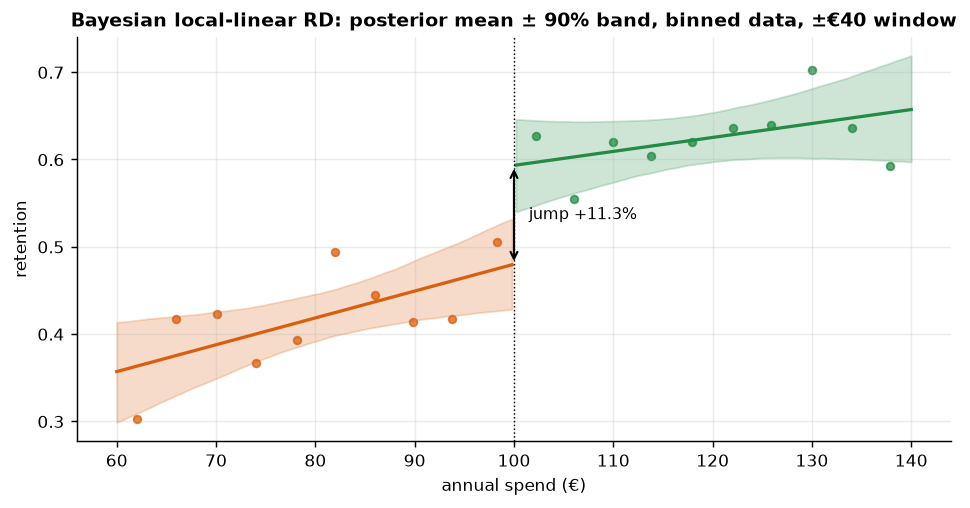

In [8]:
# --- THE canonical RD picture: the two fitted posterior lines meeting at €100 ---
bb = band.groupby("bin", observed=True).agg(spend=("spend", "mean"), ret=("retention", "mean")).dropna()
x_line = result.x_pred["spend"].values                                   # CausalPy's prediction grid (±€40)
mu_post = result.pred["posterior_predictive"]["mu"].isel(treated_units=0).stack(sample=("chain", "draw"))
line_m = mu_post.mean("sample").values
line_lo = mu_post.quantile(0.05, dim="sample").values
line_hi = mu_post.quantile(0.95, dim="sample").values
fig, ax = plt.subplots(figsize=(7.5, 4))
for side, color in [(x_line < CUTOFF, plots.ORANGE), (x_line >= CUTOFF, plots.GREEN)]:
    ax.plot(x_line[side], line_m[side], color=color, lw=1.8)
    ax.fill_between(x_line[side], line_lo[side], line_hi[side], color=color, alpha=0.22)
below_b = bb.spend < CUTOFF
ax.scatter(bb.spend[below_b], bb.ret[below_b], color=plots.ORANGE, s=18, alpha=0.75)
ax.scatter(bb.spend[~below_b], bb.ret[~below_b], color=plots.GREEN, s=18, alpha=0.75)
yb, ya = line_m[x_line < CUTOFF][-1], line_m[x_line >= CUTOFF][0]        # step endpoints at the cutoff
ax.annotate("", xy=(CUTOFF, ya), xytext=(CUTOFF, yb), arrowprops=dict(arrowstyle="<->", color="k", lw=1.2))
ax.text(CUTOFF + 1.5, (ya + yb) / 2, f"jump +{jump.mean():.1%}", fontsize=9, va="center")
ax.axvline(CUTOFF, color="k", ls=":", lw=0.8)
ax.set_xlabel("annual spend (€)"); ax.set_ylabel("retention")
ax.set_title("Bayesian local-linear RD: posterior mean ± 90% band, binned data, ±€40 window")
fig.tight_layout()
print(f"The height of the step where the two fitted lines meet at €100 IS the estimate: +{jump.mean():.1%} "
      f"(90% CrI [{np.quantile(jump, 0.05):+.1%}, {np.quantile(jump, 0.95):+.1%}]).")
print(f"Contrast: the naive Step-2b gap ({naive:+.1%}) compared the average heights of the two clouds instead.")

**This is the picture the whole method lives in.** Each dot is the average retention of a €4-wide
spend bin inside the ±€40 window; the two lines are the posterior mean of the local-linear fit on
each side, with 90% bands. **The height of the step where the two lines meet at €100 *is* the
estimate**, and the bands' separation at the cutoff is its uncertainty. Contrast this with the naive
comparison of 2b: that compared the *average height* of the orange cloud against the green cloud,
crediting the perk with the entire upward trend; RD reads only the vertical break at the threshold,
so the trend cancels. Also read the bands honestly: they are visibly wide relative to the step — that
width, not the point estimate, is what will drive the business call in Step 6.

And the promised **LPM sanity check**: refit the same window with a logit link (a likelihood that
*is* Bernoulli) and compare the implied jump in retention probability at €100.

In [9]:
import statsmodels.api as sm
sub40 = df[np.abs(df.spend - CUTOFF) <= 40]
Xl = np.column_stack([np.ones(len(sub40)), sub40.spend, sub40.treated, sub40.spend * sub40.treated])
logit_fit = sm.Logit(sub40.retention.values, Xl).fit(disp=0)
p_at = lambda s, t: logit_fit.predict(np.array([[1.0, s, t, s * t]]))[0]
logit_jump = p_at(CUTOFF, 1.0) - p_at(CUTOFF, 0.0)
print(f"Jump at €100 — linear-probability model: +{jump.mean():.1%} (Bayesian posterior mean)  ·  "
      f"logit link: {logit_jump:+.1%} — the link choice is immaterial inside a narrow window, as argued in Step 4.")

Jump at €100 — linear-probability model: +11.3% (Bayesian posterior mean)  ·  logit link: +11.2% — the link choice is immaterial inside a narrow window, as argued in Step 4.


## 5 · Validate — see the jump, plus bandwidth / placebo / polynomial robustness

A credible RD number is one that **survives** the researcher-degrees-of-freedom checks:

- **Bandwidth curve** — the estimate should be stable across a sensible range of bandwidths.
  This is **Step 0's sweep**, replotted: we compute it once, in the classical arm where the
  bandwidth choice is made, and read it here as a robustness check.
- **Placebo cutoffs** — run RD at a *grid* of fake thresholds (€60–€90 and €110–€140) where there is
  no perk; every estimated jump should be ≈ 0. A real jump at a fake cutoff would mean the method
  finds discontinuities in noise. Construction detail: below-€100 placebos use only non-Gold
  customers and above-€100 placebos only Gold customers, so no placebo window straddles the real
  jump — the standard one-sided placebo construction.
- **Polynomial order** — linear vs quadratic local fit shouldn't move the answer much. We
  deliberately stop at quadratic: Gelman & Imbens (2019) showed *high-order global* polynomials
  manufacture spurious jumps (noisy, boundary-dominated weights), which is exactly why modern RD
  practice is local-linear within a bandwidth rather than a global polynomial fit.


Bandwidth sweep (from Step 0): +7.7% … +12.5% across bw 15–60 (mean +10.8%) — every point estimate positive, but 3/10 of the narrow windows cannot exclude zero (Step 0's table).
Polynomial: linear +11.3%, quadratic +10.9%.
Placebo grid (jump, t): €60 +2.5% (t=+0.34), €70 +0.6% (t=+0.09), €80 +3.0% (t=+0.47), €90 +1.4% (t=+0.18), €110 -4.8% (t=-0.66), €120 +3.5% (t=+0.58), €130 +5.8% (t=+0.90), €140 -9.7% (t=-1.33)
Largest placebo |t| = 1.33 (at €140) — all 8 placebos statistically indistinguishable from zero; the real €100 jump's 90% CrI [+3.8%, +18.7%] excludes zero.


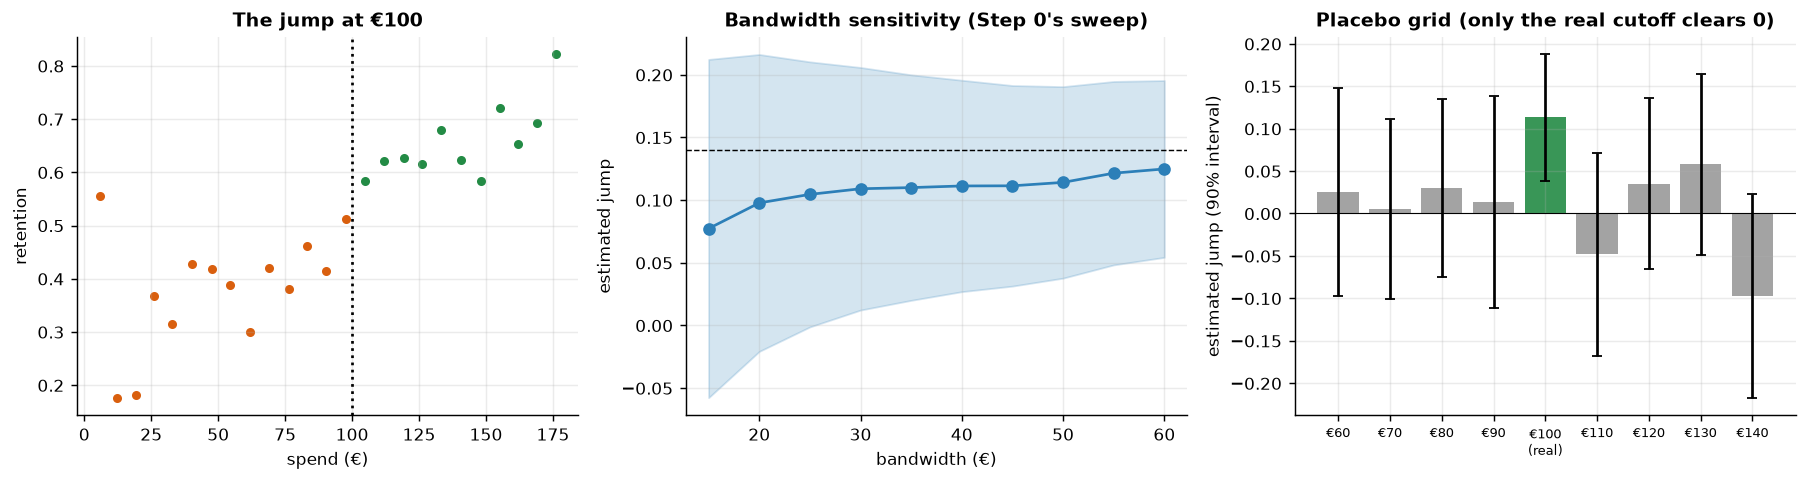

In [10]:
# CONSOLIDATED: the bandwidth sweep is Step 0's `bw_scan` (local linear, triangular kernel,
# HC1) — computed once, plotted here. No refit.
by_bw = [r.estimate for r in bw_scan]; by_se = [r.se for r in bw_scan]
# rd_jump (local-linear OLS with SE on the jump) was defined in §3c and is reused for the
# placebo grid and the polynomial check below.
# Placebo GRID: fake cutoffs €60–€90 fitted on non-Gold customers only, €110–€140 on Gold only,
# ±€25 windows — the side restriction keeps every placebo window clear of the real €100 jump.
below_cuts, above_cuts = [60, 70, 80, 90], [110, 120, 130, 140]
placebos = {c: rd_jump(df[df.spend < CUTOFF], c, 25) for c in below_cuts}
placebos.update({c: rd_jump(df[df.spend >= CUTOFF], c, 25) for c in above_cuts})
poly = {"linear": rd_jump(df, CUTOFF, 40, 1), "quadratic": rd_jump(df, CUTOFF, 40, 2)}
z90 = 1.645

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
# binned scatter
bins = np.linspace(df.spend.min(), min(df.spend.max(), 180), 26); df["bin"] = pd.cut(df.spend, bins)
b = df.groupby("bin", observed=True).agg(spend=("spend","mean"), ret=("retention","mean")).dropna()
below = b.spend < CUTOFF
ax[0].scatter(b.spend[below], b.ret[below], color=plots.ORANGE, s=16); ax[0].scatter(b.spend[~below], b.ret[~below], color=plots.GREEN, s=16)
ax[0].axvline(CUTOFF, color="k", ls=":"); ax[0].set_xlabel("spend (€)"); ax[0].set_ylabel("retention"); ax[0].set_title("The jump at €100")
# bandwidth curve
ax[1].plot(bws, by_bw, color=plots.BLUE, marker="o"); ax[1].axhline(true_jump, color="k", ls="--", lw=0.8)
ax[1].fill_between(bws, np.array(by_bw)-z90*np.array(by_se), np.array(by_bw)+z90*np.array(by_se), color=plots.BLUE, alpha=0.2)
ax[1].set_xlabel("bandwidth (€)"); ax[1].set_ylabel("estimated jump"); ax[1].set_title("Bandwidth sensitivity (Step 0's sweep)")
# placebo grid WITH 90% intervals — real cutoff = CausalPy posterior CI; placebos = local-linear ±1.645·SE
real_lo, real_hi = np.quantile(jump, 0.05), np.quantile(jump, 0.95)
cuts_order = below_cuts + [100] + above_cuts
labels = [f"€{c}" if c != 100 else "€100\n(real)" for c in cuts_order]
vals   = [placebos[c][0] if c != 100 else jump.mean() for c in cuts_order]
err_lo = [z90*placebos[c][1] if c != 100 else jump.mean()-real_lo for c in cuts_order]
err_hi = [z90*placebos[c][1] if c != 100 else real_hi-jump.mean() for c in cuts_order]
colors = [plots.GREY if c != 100 else plots.GREEN for c in cuts_order]
ax[2].bar(labels, vals, yerr=[err_lo, err_hi], capsize=3, color=colors, alpha=0.9)
ax[2].tick_params(axis="x", labelsize=7)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_ylabel("estimated jump (90% interval)"); ax[2].set_title("Placebo grid (only the real cutoff clears 0)")
fig.tight_layout()
placebo_t = {c: placebos[c][0] / placebos[c][1] for c in placebos}
c_max = max(placebo_t, key=lambda c: abs(placebo_t[c])); max_t = abs(placebo_t[c_max])
print(f"Bandwidth sweep (from Step 0): +{min(by_bw):.1%} … +{max(by_bw):.1%} across bw "
      f"{bws.min()}–{bws.max()} (mean +{np.mean(by_bw):.1%}) — every point estimate positive, but "
      f"{sum(not r.significant for r in bw_scan)}/{len(bw_scan)} of the narrow windows cannot exclude zero (Step 0's table).")
print(f"Polynomial: linear +{poly['linear'][0]:.1%}, quadratic +{poly['quadratic'][0]:.1%}.")
print("Placebo grid (jump, t): " + ", ".join(f"€{c} {placebos[c][0]:+.1%} (t={placebo_t[c]:+.2f})" for c in cuts_order if c != 100))
print(f"Largest placebo |t| = {max_t:.2f} (at €{c_max}) — all {len(placebos)} placebos statistically indistinguishable "
      f"from zero; the real €100 jump's 90% CrI [+{real_lo:.1%}, +{real_hi:.1%}] excludes zero.")

**How to read the robustness battery.** *Left* — bin retention by spend and you can *see* the step at €100
sitting on top of the smooth "big spenders retain more" trend; that step is the perk effect. *Middle* — the
estimate **drifts mildly** with the bandwidth (narrow windows are noisier, wider ones pull in curvature): every
point estimate is positive and every interval covers the planted truth, so we're not cherry-picking a window —
but read it with Step 0's table open, because the narrow windows' intervals do *not* exclude zero, and that is
the uncertainty about $h$ which neither the confidence interval nor the credible interval prices.
*Right* — the decisive check, now a **grid of eight fake cutoffs with 90% intervals**: re-run the same
local-linear RD at €60–€90 (non-Gold customers only) and €110–€140 (Gold only), where no perk switches.
The point estimates wobble around zero — one or two bars always *look* sizeable (with eight draws from
noise, they should!), but read each bar's *interval*, not its height: every placebo interval comfortably
spans zero and every |t| is under 2, with the largest flagged in the printout so you can check it rather
than trust us. Only the **real** €100 cutoff has an interval that **excludes** zero. That is the honest
test — a *family* of t-stats, not an eyeball. Together with the McCrary density, the covariate-continuity
check, and the linear-vs-quadratic agreement, it's the full case that the jump is a real causal effect,
not an artefact of how we drew the lines.

*(Implementation note: for speed, the battery's refits are local-linear **OLS approximations** of the same specification, judged on frequentist t-stats; the headline €100-cutoff estimate itself stays fully Bayesian.)*


### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each) and check both.

RD jump across 25 seeds: mean +13.8% (true +14%)  bias -0.2%  sd 4.3%  ·  90% CI covers truth in 23/25 seeds — near-nominal calibration.


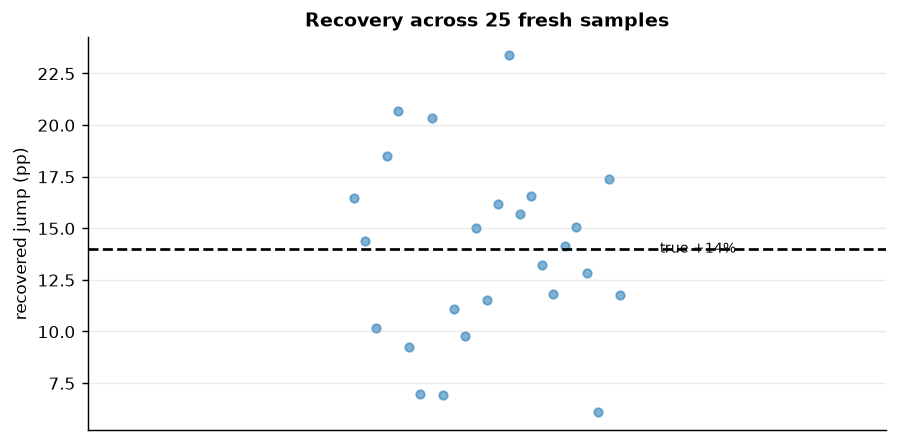

In [11]:
# --- Recovery across many seeds: does the RD jump recover +14pp and cover it? (fast OLS local-linear) ---
NSEED = 12 if FAST else 25
pts = []; cov = 0; z90 = 1.645
for sd in range(NSEED):
    d, tj = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=200 + sd)
    d["treated"] = d["treated"].astype(int)
    j, se = rd_jump(d, CUTOFF, 40, 1)
    pts.append(j); cov += int(abs(j - tj) <= z90 * se)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts * 100, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(TRUE * 100, color="k", ls="--"); ax.text(0.26, TRUE * 100, f"true +{TRUE:.0%}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered jump (pp)")
ax.set_title(f"Recovery across {NSEED} fresh samples"); fig.tight_layout()
print(f"RD jump across {NSEED} seeds: mean +{pts.mean():.1%} (true +{TRUE:.0%})  bias {pts.mean()-TRUE:+.1%}  "
      f"sd {pts.std():.1%}  ·  90% CI covers truth in {cov}/{NSEED} seeds — near-nominal calibration.")

### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

In [12]:
# --- 5x · The classical RD vs the Bayesian RD, SAME estimand, SAME bandwidth ---------------
# Like-for-like: CausalPy fits the ±€40 window UNWEIGHTED, so the exact classical twin of the
# Step-4 model is the uniform-kernel local linear fit; the triangular fit is the canonical
# classical RD of Step 0. Both are reported, so the kernel cannot hide in the comparison.
rd_unif = cl.rd_local_linear(df, outcome="retention", running="spend", cutoff=CUTOFF,
                             bandwidth=H, kernel="uniform")
b_lo, b_hi = np.quantile(jump, [0.05, 0.95])

rows = [("classical RD · triangular kernel", rd_cl.estimate, *rd_cl.ci),
        ("classical RD · uniform kernel (= §4's spec)", rd_unif.estimate, *rd_unif.ci),
        ("Bayesian RD · CausalPy (§4)", jump.mean(), b_lo, b_hi)]
print(f"SAME estimand (the jump at €100), SAME assumption (continuity), SAME bandwidth (±€{H:.0f}).")
print(f"Planted truth = +{TRUE:.0%}.  (Both classical rows: HC1 standard errors.)\n")
print(f"{'jump at €100 (pp)':<44}{'est':>6}{'5%':>6}{'95%':>6}{'± half':>8}")
for lab, e, lo, hi in rows:
    print(f"{lab:<44}{100*e:>6.1f}{100*lo:>6.1f}{100*hi:>6.1f}{100*(hi-lo)/2:>8.1f}")

ests = np.array([r[1] for r in rows]); halves = np.array([(r[3] - r[2]) / 2 for r in rows])
print(f"\nLOCATION — the three point estimates span {100*np.ptp(ests):.1f}pp "
      f"({100*ests.min():.1f}–{100*ests.max():.1f}pp), and all three intervals cover the truth.")
print(f"WIDTH — the half-widths span {100*halves.min():.1f}–{100*halves.max():.1f}pp: the posterior is "
      f"{halves[2]/halves[1]:.2f}x the width of its exact classical twin (uniform kernel).")
print("  With ~1,700 customers in the window and CausalPy's effectively-flat priors (§4), the")
print("  posterior IS the least-squares answer, re-expressed. Bayes did not move the number,")
print("  and it did not sharpen it.\n")

# The thing only a posterior can answer: a probability ABOUT the effect.
# (§6's two stated inputs, needed here one section early: a €15/member perk against a €200
#  member-year, so the perk breaks even at a retention jump of 15/200 = 7.5pp.)
PERK_COST_5X, ANNUAL_VALUE_5X = 15.0, 200.0
print("P(jump > x) — a probability about the effect itself, at three thresholds that matter:")
print(f"  {'x':<47}{'classical':>13}{'Bayes':>7}")
for x, why in [(0.0, "any effect at all"),
               (PERK_COST_5X / ANNUAL_VALUE_5X, "the perk's break-even, §6"),
               (0.10, "'material' to the retention team")]:
    print(f"  {f'{100*x:.1f}pp  ({why})':<47}{'not defined':>13}{(jump > x).mean():>7.2f}")
print("  ('not defined' is not a dodge: a confidence interval has no probability to report")
print("   about a hypothesis. §6's go/no-go rule is built on the middle row.)")

SAME estimand (the jump at €100), SAME assumption (continuity), SAME bandwidth (±€40).
Planted truth = +14%.  (Both classical rows: HC1 standard errors.)

jump at €100 (pp)                              est    5%   95%  ± half
classical RD · triangular kernel              11.1   2.7  19.6     8.4
classical RD · uniform kernel (= §4's spec)   11.3   3.6  18.9     7.7
Bayesian RD · CausalPy (§4)                   11.3   3.8  18.7     7.5

LOCATION — the three point estimates span 0.2pp (11.1–11.3pp), and all three intervals cover the truth.
WIDTH — the half-widths span 7.5–8.4pp: the posterior is 0.97x the width of its exact classical twin (uniform kernel).
  With ~1,700 customers in the window and CausalPy's effectively-flat priors (§4), the
  posterior IS the least-squares answer, re-expressed. Bayes did not move the number,
  and it did not sharpen it.

P(jump > x) — a probability about the effect itself, at three thresholds that matter:
  x                                             

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They agree, and you should say so out loud.** The classical local-linear RD of Step 0 and the
Bayesian RD of Step 4 land on the same jump, to within a fraction of a percentage point (table above),
with intervals of nearly the same width — and the logit refit in §4 said the same thing a third time.
That is not a coincidence and it is not a disappointment: **the causal work was done by the
identification, not by the machinery.** Continuity at €100 is what turns a difference of fitted
intercepts into a causal effect; once that argument is granted, a Bayesian regression with flat priors
and ~1,700 customers in the window is doing arithmetic weighted least squares had already done. If you
were hoping "going Bayesian" would move the point estimate, this notebook is the correction: with data
this plentiful and priors this weak, it must not, and it does not.

**2 · What Bayes did NOT buy here — be specific.** It did not buy precision: the posterior's 90%
credible interval and the HC1 confidence interval come out within a few percent of each other in width
(the ratio is printed above), because they are both reading the same likelihood surface. It did not buy a better point estimate. And — the one that
matters most in an RD — **it did not solve the bandwidth problem either.** The Step-4 posterior is just
as conditional on $h = \pm€40$ as Step 0's confidence interval is; a prior over $h$ (or a model that
integrates it out) would be needed for that, and the CausalPy fit does not have one. The Step-0
bandwidth table remains the honest statement of that uncertainty, and it is *wider* than either
interval printed here. Do not let the credible interval's Bayesian label launder a tuning choice
neither arm has priced.

**3 · What the posterior *does* buy — the last block of the print-out.** Look at the `P(jump > x)`
column. The classical row reads *not defined*, and that is the literal truth rather than a rhetorical
concession: the frequentist apparatus attaches no probability to a hypothesis about a fixed parameter.
Yet the €-decision in §6 is *nothing but* such a probability — *P(retention lift × €200 member-year >
€15 perk cost)* — and the perk-cost sweep, the conservative break-even, and the value-of-information
calculation are all just that same posterior, pushed through arithmetic. Each of them propagates the
full shape of the uncertainty (not merely two interval endpoints) into the renewal call. And the answer
it returns is the interesting one: **P(perk pays) lands short of the 0.9 bar**, which is a *reconsider*,
not a *keep* — a verdict the classical arm's "the CI excludes zero, so it works" could never have
reached.

> **Bayes did not rescue the estimate here — it was never in danger, and the classical estimator got
> the same number with the same width on the first attempt. Bayes bought the right to make a
> probability statement about the effect, which is the statement the business actually asked for.**

That is the honest size of the win, and — in a notebook whose whole job is a go/no-go on a €15 perk —
it is enough.

## 6 · Decide, in euros — does the perk pay, and where to set the cutoff?

Value the retention lift: extra retained customers × annual value, minus the perk cost, **at the
current €100 margin** (that's what RD identifies). We also sweep the perk cost to find the
break-even.

> **What RD can and can't answer.** RD identifies *only* the local effect at the €100 margin — it tells us whether the perk pays **there**, but it **cannot** tell us where to set the cutoff (moving the threshold extrapolates beyond the RD's local validity; that question needs an experiment or multi-cutoff data).
>
> **Two stated inputs.** `N_AT_MARGIN ≈ 3,000` is an illustrative **per-cycle inflow** of members passing the €100 margin — a modeling input, distinct from this snapshot's in-sample ±€40 window (which holds ~1,700 members, printed in the value-of-information readout below); swap in your CRM's number; the **0.9** go/no-go bar is the cookbook's convention for "sure enough to act without a further test".

Net €7.7/member  ·  total €22,960 [90% €-22,140, €67,444]
P(perk pays) 0.80 → reconsider  ·  break-even perk cost ≈ €8/member (conservative).
Perk-cost sweep €0–30: P(perk pays) falls 0.99 → 0.21; at the actual €15 cost P(pays) = 0.80, E[net] = €8/member (break-even €8).


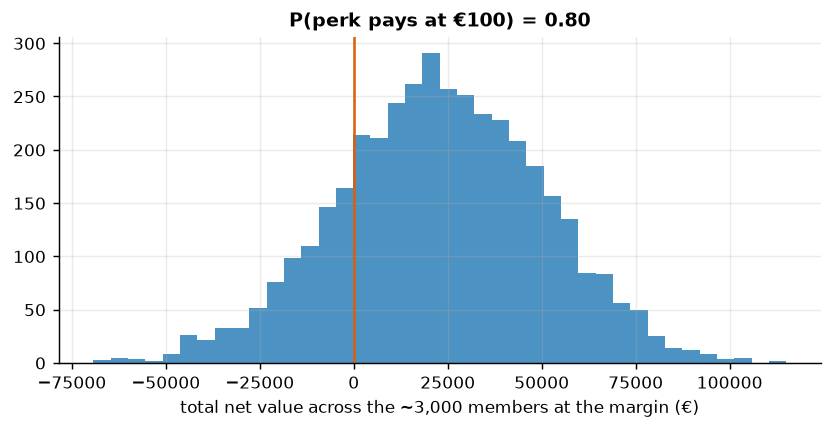

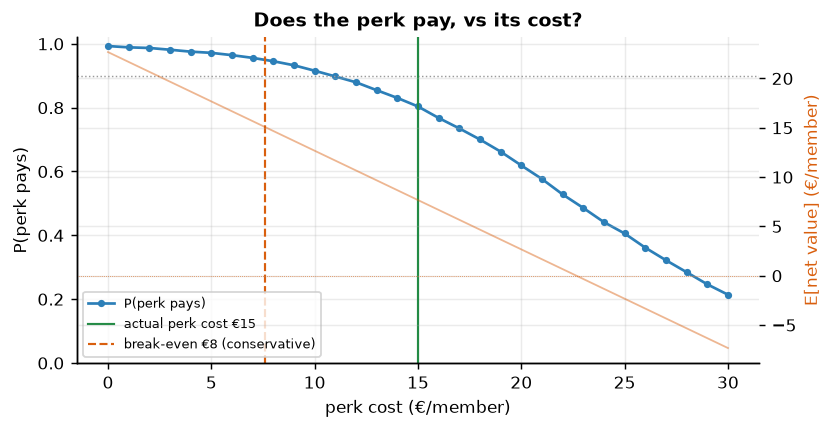

In [13]:
ANNUAL_VALUE, PERK_COST, N_AT_MARGIN = 200.0, 15.0, 3000
value = jump * ANNUAL_VALUE - PERK_COST
total = value * N_AT_MARGIN
p_worth = (value > 0).mean()
be_perk = np.quantile(jump, 0.05) * ANNUAL_VALUE      # perk cost the effect can bear (conservative)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(total, bins=40, color=plots.BLUE, alpha=0.85); ax.axvline(0, color=plots.ORANGE, lw=1.4)
ax.set_xlabel("total net value across the ~3,000 members at the margin (€)"); ax.set_title(f"P(perk pays at €100) = {p_worth:.2f}"); fig.tight_layout()
print(f"Net €{value.mean():.1f}/member  ·  total €{total.mean():,.0f} [90% €{np.quantile(total,0.05):,.0f}, €{np.quantile(total,0.95):,.0f}]")
print(f"P(perk pays) {p_worth:.2f} → " + ("KEEP the perk at the €100 margin" if p_worth>0.9 else "reconsider") +
      f"  ·  break-even perk cost ≈ €{be_perk:.0f}/member (conservative).")

# --- Perk-cost sweep (promised above): P(perk pays) and E[net value] vs the perk's cost.
#     RD identifies ONLY the local effect at €100, so this sizes the decision AT THIS MARGIN. ---
perk_grid = np.linspace(0, 30, 31)
gross = jump * ANNUAL_VALUE                        # posterior of gross retention value / member at the €100 margin
p_pays = np.array([(gross > pc).mean() for pc in perk_grid])
e_net  = gross.mean() - perk_grid                  # E[net value] / member at each perk cost
figc, axc = plt.subplots(figsize=(6.5, 3.4))
axc.plot(perk_grid, p_pays, color=plots.BLUE, marker="o", ms=3, label="P(perk pays)")
axc.axhline(0.9, color=plots.GREY, ls=":", lw=0.8)
axc.axvline(PERK_COST, color=plots.GREEN, lw=1.2, label=f"actual perk cost €{PERK_COST:.0f}")
axc.axvline(be_perk, color=plots.ORANGE, ls="--", lw=1.2, label=f"break-even €{be_perk:.0f} (conservative)")
axc.set_xlabel("perk cost (€/member)"); axc.set_ylabel("P(perk pays)"); axc.set_ylim(0, 1.02)
axc.set_title("Does the perk pay, vs its cost?"); axc.legend(fontsize=7, loc="lower left")
axt = axc.twinx(); axt.plot(perk_grid, e_net, color=plots.ORANGE, alpha=0.45, lw=1.0)
axt.axhline(0, color=plots.ORANGE, lw=0.4, ls=":"); axt.set_ylabel("E[net value] (€/member)", color=plots.ORANGE)
figc.tight_layout()
print(f"Perk-cost sweep €0–30: P(perk pays) falls {p_pays[0]:.2f} → {p_pays[-1]:.2f}; at the actual €{PERK_COST:.0f} "
      f"cost P(pays) = {(gross > PERK_COST).mean():.2f}, E[net] = €{gross.mean()-PERK_COST:.0f}/member (break-even €{be_perk:.0f}).")

**How to read the decision histogram.** Mass to the right of the orange zero line = P(perk pays); the wide spread — *not* the positive mean — is what makes this a *reconsider / TEST* call.

**And the sweep turns it into a negotiation.** At the actual €15 perk cost, P(pays) comes out around 0.8 (printed above) — real
but below the 0.9 bar — while the *conservative* break-even (the cost the 5th-percentile effect
still covers) sits at ≈ €8/member (exact value printed above). So the decision isn't "keep or kill": it's **either bring the perk's
cost toward the break-even** (a cheaper perk with the same salience keeps the retention jump and clears the
bar by construction) **or buy more certainty before renewing** — a longer measurement horizon or a
wider eligibility window around the cutoff, both of which tighten the jump posterior. What the
sweep must *not* be used for is moving the €100 threshold itself: RD's evidence is local to the
customers near €100 (the blockquote above), and pricing a new cutoff from this posterior would be
extrapolation dressed as analysis.

How much certainty would more data actually buy? The next cell quantifies it — the last input
the memo needs.

In [14]:
# --- Value of information: the jump posterior's sd shrinks ≈ 1/sqrt(n in window). What would more data buy?
#     (normal approximation to the posterior of gross €/member; same posterior mean assumed to hold) ---
from scipy.stats import norm
n_bw = int((np.abs(df.spend - CUTOFF) <= 40).sum())
m_g, s_g = gross.mean(), gross.std()                       # posterior of gross € value per marginal member
p_now = float((gross > PERK_COST).mean())
p_2x = float(norm.cdf((m_g - PERK_COST) / (s_g / np.sqrt(2))))     # ~2x window members = one more cycle
sd_req = (m_g - PERK_COST) / norm.ppf(0.9)                 # posterior sd that puts P(pays) at exactly 0.9
factor = (s_g / sd_req) ** 2 if sd_req > 0 else float("inf")
print(f"Members in the ±€40 window this cycle: {n_bw:,}  ·  P(perk pays €{PERK_COST:.0f}) now: {p_now:.2f}")
print(f"One more cycle of data (≈ 2x the window sample): CrI ≈ 29% tighter → P(pays) ≈ {p_2x:.2f} if the mean holds.")
print(f"Clearing the 0.9 bar at the current cost needs posterior sd €{s_g:.1f} → €{sd_req:.1f}/member, "
      f"i.e. ≈ {factor:.1f}x the window sample — which is why renegotiating the perk's cost is the stronger lever.")

Members in the ±€40 window this cycle: 1,706  ·  P(perk pays €15) now: 0.80
One more cycle of data (≈ 2x the window sample): CrI ≈ 29% tighter → P(pays) ≈ 0.88 if the mean holds.
Clearing the 0.9 bar at the current cost needs posterior sd €9.1 → €6.0/member, i.e. ≈ 2.3x the window sample — which is why renegotiating the perk's cost is the stronger lever.


### The one-paragraph decision

> **To the CMO.** The Gold perk causes a real retention lift for customers at the €100 margin —
> a jump of roughly eleven percentage points (exact posterior printed in Step 4), an estimate that
> survives a density check, covariate continuity, eight placebo cutoffs, bandwidth and polynomial
> sweeps, and a multi-seed calibration study. At the current €15/member cost it pays *in
> expectation* (order €20k per cycle across the ~3,000 marginal members), but the probability it
> pays is only ≈ 0.8 — below our 0.9 action bar. So: **don't kill it, and don't blindly renew it.**
> Either (a) renegotiate the perk's cost down toward the conservative break-even printed in Step 6 —
> the cost even the 5th-percentile effect covers, which clears the bar by construction — or (b) buy
> certainty: the value-of-information readout above shows one more cycle of margin data tightens the
> interval ~30% and lifts P(pays) toward the bar *if the point estimate holds*, while clearing 0.9
> outright at the current cost would take more than twice the data again (the exact factor is
> printed above). Cost renegotiation is the stronger
> lever; more data is the fallback.
>
> **And the threshold question the title poses?** RD alone **cannot** answer "where should the
> threshold be": it measures the effect at €100 and nothing in the data distinguishes a constant
> jump from one that decays away from the cutoff — formally, $\tau(s)$ is identified only at
> $s = c$ (our DGP happens to make it constant; a real perk needn't be). The design answer: **randomize
> the cutoff** — a tier experiment assigning €90 / €100 / €110 thresholds across regions or cohorts
> traces $\tau(s)$ at three points and prices the threshold directly; failing that, a past threshold
> change gives a second cutoff for a multi-cutoff RD. Moving the threshold on the strength of one
> local estimate would be extrapolation dressed as analysis.

## 7 · Caveats

- **RD is *local*.** The effect is identified only *at the cutoff* — the perk's effect on customers
  near €100, not on your €500 whales. Don't extrapolate the jump to everyone.
- **Manipulation breaks it.** We checked the McCrary density and covariate continuity; watch for heaping
  at round numbers. If the observations *nearest* the threshold are suspect (heaping, gamed baskets),
  the standard remedy is a **donut RD** — drop observations within ±ε of the cutoff and refit
  (CausalPy exposes this as `donut_hole`).
- **Bandwidth is bias–variance — and *neither* arm prices it.** The estimate drifts mildly with the
  window (narrow = noisier, wide = more curvature) but stays positive here; an estimate that *swings
  across zero* with bandwidth would be a red flag. Both the classical confidence interval (Step 0) and
  the Bayesian credible interval (Step 4) are **conditional on ±€40** — the Step-0 sweep, not either
  interval, is the honest statement of how much the window choice moves the answer (5x).
- **Fuzzy RD if the rule isn't sharp.** If crossing €100 only *raises the probability* of Gold
  (grandfathering, overrides), use the fuzzy-RD ratio (jump in Y ÷ jump in P(treated)) — this ratio is exactly the Wald/IV estimator of notebook 11, with the threshold acting as the instrument (estimand formalized in Step 3).

---
## Book export

Chapter 11 of the book (`book/chapters/rdd.tex`) is built from this notebook and **does not retype a
single number**. Every figure it prints — every percentage point, $t$-statistic, placebo, `P(perk pays)`,
table cell and plot — is *emitted* below by `cmp.report` into `book/build/results/nb09.json`, from which
`book/build.py` generates `macros.tex`, the booktabs tables and the vector figures the chapter `\input`s.
A number that goes stale is impossible; a number that goes *missing* is a LaTeX compile error rather than
a silent hole. The cell adds no output of its own — the notebook above is unchanged.

In [15]:
# ---------------------------------------------------------------- Book export (cmp.report)
# Chapter 11 of the book (`book/chapters/rdd.tex`) never retypes a number: every figure it
# prints — every percentage point, t-statistic, P(pays), table cell and plot — is emitted HERE,
# from this executed run, into book/build/results/nb09.json -> macros.tex (see src/cmp/report.py).
# A stale number is impossible; a missing one is a LaTeX compile error rather than a silent hole.
# Figures are re-rendered in book style (vector PDF, larger type, no in-figure title — the caption
# carries the takeaway) and closed immediately, so this cell changes nothing the notebook shows.
import matplotlib as mpl
from cmp import report as R

def V(k, v, **kw):
    return R.value(f"nb09.{k}", v, **kw)

conv = est.convergence_report(result.idata)
tri_half = (rd_cl.ci[1] - rd_cl.ci[0]) / 2
unif_half = (rd_unif.ci[1] - rd_unif.ci[0]) / 2
bayes_half = (b_hi - b_lo) / 2
BE = PERK_COST / ANNUAL_VALUE                      # the jump at which the perk breaks even

# --- the world, and the planted truth --------------------------------------------------
V("n", int(len(df)), fmt=",d")
V("cutoff", int(CUTOFF), fmt="d")
V("true_jump", 100 * TRUE, fmt=".0f", note="planted jump, percentage points")
V("gold_share", 100 * float((df.spend >= CUTOFF).mean()), fmt=".0f")
V("seed", int(SEED), fmt="d")

# --- the naive dashboard comparison ----------------------------------------------------
V("naive", 100 * float(naive_cl.estimate), fmt="+.1f")
V("naive_lo", 100 * float(naive_cl.ci[0]), fmt="+.1f")
V("naive_hi", 100 * float(naive_cl.ci[1]), fmt="+.1f")
V("naive_se", 100 * float(naive_cl.se), fmt=".1f")
V("naive_width", 100 * float(naive_cl.ci[1] - naive_cl.ci[0]), fmt=".1f")
V("naive_bias", 100 * float(naive_cl.estimate - TRUE), fmt="+.1f")
V("naive_cov", naive_cl.cov)
V("naive_verdict", "inside" if naive_cl.ci[0] <= TRUE <= naive_cl.ci[1] else "outside")
V("selection_closed_form", 100 * float(pred_selection), fmt="+.1f")

# --- the classical RD ------------------------------------------------------------------
V("h", int(H), fmt="d")
V("rd", 100 * float(rd_cl.estimate), fmt="+.1f")
V("rd_lo", 100 * float(rd_cl.ci[0]), fmt="+.1f")
V("rd_hi", 100 * float(rd_cl.ci[1]), fmt="+.1f")
V("rd_se", 100 * float(rd_cl.se), fmt=".1f")
V("rd_half", 100 * float(tri_half), fmt=".1f")
V("rd_width", 100 * float(rd_cl.ci[1] - rd_cl.ci[0]), fmt=".1f")
V("rd_err", 100 * float(rd_cl.estimate - TRUE), fmt="+.1f")
V("rd_verdict", "inside" if rd_cl.ci[0] <= TRUE <= rd_cl.ci[1] else "outside")
V("rd_n", int(rd_cl.n), fmt=",d")
V("rd_n_left", int(rd_cl.extra["n_left"]), fmt=",d")
V("rd_n_right", int(rd_cl.extra["n_right"]), fmt=",d")
V("rd_dropped", int(len(df) - rd_cl.n), fmt=",d")
V("rd_dropped_pct", 100 * (len(df) - rd_cl.n) / len(df), fmt=".0f")
V("rd_cov", rd_cl.cov)
V("width_vs_naive", float((rd_cl.ci[1] - rd_cl.ci[0]) / (naive_cl.ci[1] - naive_cl.ci[0])), fmt=".1f")

# --- the bandwidth sweep — the chapter's honest weakness --------------------------------
V("bw_min", int(bws.min()), fmt="d")
V("bw_max", int(bws.max()), fmt="d")
V("bw_n_windows", int(len(bw_scan)), fmt="d")
V("bw_est_lo", 100 * float(e_grid.min()), fmt="+.1f")
V("bw_est_hi", 100 * float(e_grid.max()), fmt="+.1f")
V("bw_est_range", 100 * float(np.ptp(e_grid)), fmt=".1f")
V("bw_est_mean", 100 * float(e_grid.mean()), fmt="+.1f")
V("bw_n_insignif", int(sum(not r.significant for r in bw_scan)), fmt="d")
V("bw_n_covers", int(sum(r.ci[0] <= TRUE <= r.ci[1] for r in bw_scan)), fmt="d")
V("bw_union_lo", 100 * float(env_lo), fmt="+.1f")
V("bw_union_hi", 100 * float(env_hi), fmt="+.1f")
V("bw_union_width", 100 * float(env_hi - env_lo), fmt=".1f")
V("bw_range_over_half", 100 * float(np.ptp(e_grid) / tri_half), fmt=".0f")
V("bw_union_over_width", float((env_hi - env_lo) / (rd_cl.ci[1] - rd_cl.ci[0])), fmt=".1f")

# --- the diagnostics -------------------------------------------------------------------
V("mcc_bw", 15, fmt="d")
V("mcc_below", float(d_below), fmt=".1f")
V("mcc_above", float(d_above), fmt=".1f")
V("mcc_log_ratio", float(log_ratio), fmt="+.2f")
V("mcc_z", float(z_mcc), fmt="+.2f")
V("cov_tenure", float(cov_checks["tenure_m"][0]), fmt="+.2f")
V("cov_tenure_t", float(cov_checks["tenure_m"][0] / cov_checks["tenure_m"][1]), fmt="+.2f")
V("cov_orders", float(cov_checks["n_orders"][0]), fmt="+.2f")
V("cov_orders_t", float(cov_checks["n_orders"][0] / cov_checks["n_orders"][1]), fmt="+.2f")
V("placebo_n", int(len(placebos)), fmt="d")
V("placebo_max_t", float(max_t), fmt=".2f")
V("placebo_max_cut", int(c_max), fmt="d")
V("placebo_bw", 25, fmt="d")
V("placebo_max_jump", 100 * float(placebos[c_max][0]), fmt="+.1f")
V("poly_linear", 100 * float(poly["linear"][0]), fmt="+.1f")
V("poly_quadratic", 100 * float(poly["quadratic"][0]), fmt="+.1f")
V("poly_diff", 100 * abs(float(poly["quadratic"][0] - poly["linear"][0])), fmt=".1f")
V("logit_jump", 100 * float(logit_jump), fmt="+.1f")
V("logit_diff", 100 * abs(float(logit_jump - jump.mean())), fmt=".1f")

# --- recovery across fresh samples -----------------------------------------------------
V("n_seeds", int(NSEED), fmt="d")
V("seed_mean", 100 * float(pts.mean()), fmt="+.1f")
V("seed_bias", 100 * float(pts.mean() - TRUE), fmt="+.1f")
V("seed_sd", 100 * float(pts.std()), fmt=".1f")
V("seed_cov_n", int(cov), fmt="d")
V("seed_cov_pct", 100 * cov / NSEED, fmt=".0f")

# --- the Bayesian arm ------------------------------------------------------------------
V("bayes", 100 * float(jump.mean()), fmt="+.1f")
V("bayes_lo", 100 * float(b_lo), fmt="+.1f")
V("bayes_hi", 100 * float(b_hi), fmt="+.1f")
V("bayes_half", 100 * float(bayes_half), fmt=".1f")
V("bayes_width", 100 * float(b_hi - b_lo), fmt=".1f")
V("bayes_sd", 100 * float(jump.std()), fmt=".1f")
V("n_draws", int(jump.size), fmt=",d")
V("rhat", float(conv["max_rhat"]), fmt=".3f")
V("ess", float(conv["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(conv["n_divergences"]), fmt="d")
V("unif", 100 * float(rd_unif.estimate), fmt="+.1f")
V("unif_lo", 100 * float(rd_unif.ci[0]), fmt="+.1f")
V("unif_hi", 100 * float(rd_unif.ci[1]), fmt="+.1f")
V("unif_half", 100 * float(unif_half), fmt=".1f")
V("width_ratio", float(bayes_half / unif_half), fmt=".2f")
V("est_span", 100 * float(np.ptp(ests)), fmt=".1f")
V("est_diff", 100 * abs(float(jump.mean() - rd_cl.estimate)), fmt=".1f")
V("p_gt_zero", float((jump > 0).mean()), fmt=".2f")
V("p_gt_be", float((jump > BE).mean()), fmt=".2f")
V("p_gt_material", float((jump > 0.10).mean()), fmt=".2f")

# --- the decision, in euros ------------------------------------------------------------
V("perk_cost", int(PERK_COST), fmt="d")
V("annual_value", int(ANNUAL_VALUE), fmt=",d")
V("n_margin", int(N_AT_MARGIN), fmt=",d")
V("breakeven_jump", 100 * BE, fmt=".1f")
V("p_pays", float(p_worth), fmt=".2f")
V("action_bar", 0.9, fmt=".1f")
V("decision", "keep" if p_worth > 0.9 else "reconsider")
V("net_member", float(value.mean()), unit="EUR", fmt=".1f")
V("total_net", float(total.mean()), unit="EUR", fmt=",.0f")
V("total_lo", float(np.quantile(total, 0.05)), unit="EUR", fmt=",.0f")
V("total_hi", float(np.quantile(total, 0.95)), unit="EUR", fmt=",.0f")
V("be_perk", float(be_perk), unit="EUR", fmt=".0f")
V("p_pays_free", float(p_pays[0]), fmt=".2f")
V("p_pays_dear", float(p_pays[-1]), fmt=".2f")
V("perk_grid_hi", int(perk_grid.max()), fmt="d")

# --- the value of information ----------------------------------------------------------
V("n_window", int(n_bw), fmt=",d")
V("p_pays_next", float(p_2x), fmt=".2f")
V("cri_shrink", 100 * (1 - 1 / np.sqrt(2)), fmt=".0f")
V("sd_now", float(s_g), unit="EUR", fmt=".1f")
V("sd_req", float(sd_req), unit="EUR", fmt=".1f")
V("data_factor", float(factor), fmt=".1f")

# --- tables ----------------------------------------------------------------------------
_pp = lambda x: f"{100 * x:+.1f}"
_ci = lambda r: f"[{100 * r[0]:+.1f}, {100 * r[1]:+.1f}]"
_t_ten, _t_ord = cov_checks["tenure_m"], cov_checks["n_orders"]

R.table(pd.DataFrame([
    {"Estimator": "Naive: Gold vs. everyone else", "n": f"{naive_cl.n:,}",
     "Jump (pp)": _pp(naive_cl.estimate), "90 % CI": _ci(naive_cl.ci),
     "Width (pp)": f"{100 * (naive_cl.ci[1] - naive_cl.ci[0]):.1f}",
     "Truth in?": "yes" if naive_cl.ci[0] <= TRUE <= naive_cl.ci[1] else "NO"},
    {"Estimator": "RD: local linear, triangular kernel", "n": f"{rd_cl.n:,}",
     "Jump (pp)": _pp(rd_cl.estimate), "90 % CI": _ci(rd_cl.ci),
     "Width (pp)": f"{100 * (rd_cl.ci[1] - rd_cl.ci[0]):.1f}",
     "Truth in?": "yes" if rd_cl.ci[0] <= TRUE <= rd_cl.ci[1] else "NO"},
]), "nb09.naivetable", align=r">{\raggedright\arraybackslash}p{5.4cm}rrrrc",
    caption=(f"A tight interval around the wrong number. Two estimators, the same {len(df):,} "
             f"customers, the same planted jump of {100 * TRUE:.0f}\\,pp; the RD row is fitted at "
             f"$h = {H:.0f}$ EUR. The naive Gold-vs-rest "
             f"comparison is "
             f"{(naive_cl.ci[1] - naive_cl.ci[0]) / (rd_cl.ci[1] - rd_cl.ci[0]):.1f} times more "
             f"\\emph{{precise}} than the RD estimate --- and its interval excludes the truth. The RD "
             f"estimate discards {len(df) - rd_cl.n:,} customers to buy comparability, reports an "
             f"interval {(rd_cl.ci[1] - rd_cl.ci[0]) / (naive_cl.ci[1] - naive_cl.ci[0]):.1f} times as "
             f"wide, and contains it. Precision that was not earned is not a virtue."),
    label="tab:rd:naive")

R.table(pd.DataFrame([
    {"h (EUR)": f"{h:.0f}", "n in window": f"{r.n:,}", "Jump (pp)": _pp(r.estimate),
     "90 % interval": _ci(r.ci),
     "Excludes 0?": "yes" if r.significant else "NO",
     "Covers truth?": "yes" if r.ci[0] <= TRUE <= r.ci[1] else "NO"}
    for h, r in zip(bws, bw_scan)
]), "nb09.bwsweep", align="rrrrcc",
    caption=(f"The bandwidth is a choice, not an estimate. The same estimator, the same data, "
             f"{len(bw_scan)} windows: the point estimate ranges {100 * e_grid.min():+.1f} to "
             f"{100 * e_grid.max():+.1f}\\,pp, and the \\emph{{significance verdict itself flips}} --- "
             f"{sum(not r.significant for r in bw_scan)} of {len(bw_scan)} windows cannot exclude zero. "
             f"The union of the {len(bw_scan)} intervals is "
             f"[{100 * env_lo:+.1f}, {100 * env_hi:+.1f}]\\,pp, "
             f"{(env_hi - env_lo) / (rd_cl.ci[1] - rd_cl.ci[0]):.1f} times the width of the single "
             f"interval reported at $h = {H:.0f}$. That extra width is what the reported interval is "
             f"not showing: it prices sampling noise \\emph{{given}} the window, and not the choice of "
             f"window."),
    label="tab:rd:bwsweep")

R.table(pd.DataFrame([
    {"Fake cutoff (EUR)": f"{c}",
     "Fitted on": "below-Gold customers only" if c < CUTOFF else "Gold customers only",
     "Jump (pp)": _pp(placebos[c][0]),
     "t": f"{placebos[c][0] / placebos[c][1]:+.2f}",
     "Reject zero?": "no" if abs(placebos[c][0] / placebos[c][1]) < 1.645 else "YES"}
    for c in below_cuts + above_cuts
]), "nb09.placebogrid", align="rlrrc",
    caption=(f"Eight thresholds at which nothing happened. Each row refits the identical local-linear "
             f"estimator at a fake cutoff inside a $\\pm$25\\,EUR window, restricted to one side of the "
             f"real cutoff so that no placebo window can see the real jump. All {len(placebos)} are "
             f"statistically indistinguishable from zero (largest $|t| = {max_t:.2f}$, at "
             f"{c_max}\\,EUR), while the real cutoff's interval "
             f"[{100 * real_lo:+.1f}, {100 * real_hi:+.1f}]\\,pp excludes it. The machinery does not "
             f"manufacture discontinuities; it finds the one that is there."),
    label="tab:rd:placebo")

R.table(pd.DataFrame([
    {"Arm": "Classical RD (triangular kernel)", "Est. (pp)": _pp(rd_cl.estimate),
     "5 %": f"{100 * rd_cl.ci[0]:+.1f}", "95 %": f"{100 * rd_cl.ci[1]:+.1f}",
     "Half-width": f"{100 * tri_half:.1f}",
     "Truth in?": "yes" if rd_cl.ci[0] <= TRUE <= rd_cl.ci[1] else "NO",
     "P(pays)": "undefined"},
    {"Arm": "Classical RD (uniform kernel)", "Est. (pp)": _pp(rd_unif.estimate),
     "5 %": f"{100 * rd_unif.ci[0]:+.1f}", "95 %": f"{100 * rd_unif.ci[1]:+.1f}",
     "Half-width": f"{100 * unif_half:.1f}",
     "Truth in?": "yes" if rd_unif.ci[0] <= TRUE <= rd_unif.ci[1] else "NO",
     "P(pays)": "undefined"},
    {"Arm": "Bayesian RD (posterior)", "Est. (pp)": _pp(jump.mean()),
     "5 %": f"{100 * b_lo:+.1f}", "95 %": f"{100 * b_hi:+.1f}",
     "Half-width": f"{100 * bayes_half:.1f}",
     "Truth in?": "yes" if b_lo <= TRUE <= b_hi else "NO",
     "P(pays)": f"{(jump > BE).mean():.2f}"},
]), "nb09.compare", align=r">{\raggedright\arraybackslash}p{5.1cm}rrrrcc",
    caption=(f"The same estimand (the jump at the {CUTOFF:.0f}\\,EUR cutoff), the same assumption "
             f"(continuity), the same bandwidth ($h = {H:.0f}$), two paradigms. The three point "
             f"estimates span {100 * np.ptp(ests):.1f}\\,pp and all three intervals cover the planted "
             f"{100 * TRUE:.0f}\\,pp. The posterior is {bayes_half / unif_half:.2f} times the width of "
             f"its exact classical twin: \\textbf{{Bayes did not move the number and did not sharpen "
             f"it}}. The last column is what it did buy --- a probability about the effect itself, "
             f"evaluated at the perk's break-even jump of {100 * BE:.1f}\\,pp --- and it exists in "
             f"exactly one of the three rows."),
    label="tab:rd:compare")

R.table(pd.DataFrame([
    {"Assumption": "A1 continuity of E[Y(d) | S=s] at the cutoff",
     "How it is checked": "untestable; only its implications are",
     "Statistic": "-", "Verdict": "assumed"},
    {"Assumption": "A2 no manipulation of the running variable",
     "How it is checked": "density of spend is smooth at the cutoff (McCrary-style)",
     "Statistic": f"z = {z_mcc:+.2f}", "Verdict": "pass"},
    {"Assumption": "A1, implication (i)",
     "How it is checked": "pre-determined tenure does not jump at the cutoff",
     "Statistic": f"t = {_t_ten[0] / _t_ten[1]:+.2f}", "Verdict": "pass"},
    {"Assumption": "A1, implication (ii)",
     "How it is checked": "pre-determined order count does not jump at the cutoff",
     "Statistic": f"t = {_t_ord[0] / _t_ord[1]:+.2f}", "Verdict": "pass"},
    {"Assumption": "A3 nothing else changes at the cutoff",
     "How it is checked": f"{len(placebos)} placebo cutoffs find nothing",
     "Statistic": f"max |t| = {max_t:.2f}", "Verdict": "pass"},
    {"Assumption": "A4 the local polynomial is adequate",
     "How it is checked": "linear vs. quadratic inside the same window",
     "Statistic": f"{100 * poly['linear'][0]:+.1f} vs. {100 * poly['quadratic'][0]:+.1f} pp",
     "Verdict": "pass"},
    {"Assumption": "A5 the bandwidth is the right one",
     "How it is checked": f"{len(bw_scan)} windows, {bws.min()} to {bws.max()} EUR",
     "Statistic": f"{sum(not r.significant for r in bw_scan)} of {len(bw_scan)} cannot exclude 0",
     "Verdict": "NOT SETTLED"},
]), "nb09.assumptions", align=r">{\raggedright\arraybackslash}p{3.8cm}>{\raggedright\arraybackslash}p{5.1cm}>{\raggedright\arraybackslash}p{2.5cm}l",
    caption=("Every assumption, and what was done about it. RD's diagnostics are unusually good: the "
             "design has real, observable implications, and five of the seven lines below are a test "
             "that could have failed and did not. The two that cannot be closed are the first and the "
             "last. Continuity itself is untestable --- only its implications are --- and the bandwidth "
             "is a tuning parameter whose choice no interval in this chapter prices. Neither the "
             "classical nor the Bayesian arm repairs the last line."),
    label="tab:rd:assumptions")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    # 1 · the confound, and the naive comparison that books it as effect
    f = plt.figure(figsize=(6.6, 3.3)); a = f.add_subplot(111)
    _lo, _hi = b.spend < CUTOFF, b.spend >= CUTOFF
    a.scatter(b.spend[_lo], b.ret[_lo], color=plots.ORANGE, s=20, label="below the cutoff")
    a.scatter(b.spend[_hi], b.ret[_hi], color=plots.GREEN, s=20, label="Gold")
    m0 = df.loc[df.treated == 0, "retention"].mean()
    m1 = df.loc[df.treated == 1, "retention"].mean()
    a.hlines(m0, df.spend.min(), CUTOFF, color=plots.ORANGE, ls="--", lw=1.2)
    a.hlines(m1, CUTOFF, b.spend.max(), color=plots.GREEN, ls="--", lw=1.2)
    a.annotate("", xy=(CUTOFF + 24, m1), xytext=(CUTOFF + 24, m0),
               arrowprops=dict(arrowstyle="<->", color="k", lw=1.1))
    a.text(CUTOFF + 27, (m0 + m1) / 2, f"naive gap\n{100 * naive_cl.estimate:+.1f}pp",
           fontsize=9, va="center")
    a.axvline(CUTOFF, color="k", ls=":", lw=0.9)
    a.set_xlabel("annual spend (€)"); a.set_ylabel("retention")
    a.legend(frameon=False, loc="upper left")
    f.tight_layout()
    R.figure(f, "nb09.confound", caption=(
        f"Why the dashboard number is wrong. Each dot is the mean retention of a spend bin: retention "
        f"climbs steadily with spend on \\emph{{both}} sides of the cutoff, because big spenders retain "
        f"anyway. The dashed lines are the two group means the naive comparison actually contrasts, and "
        f"the gap between them ({100 * naive_cl.estimate:+.1f}\\,pp) is the perk's true effect "
        f"({100 * TRUE:.0f}\\,pp) plus the whole climb of the confounder "
        f"({100 * (naive_cl.estimate - TRUE):+.1f}\\,pp of pure selection). Regression discontinuity "
        f"reads only the vertical break at the cutoff, so the climb cancels."),
        label="fig:rd:confound")
    plt.close(f)

    # 2 · McCrary density
    f = plt.figure(figsize=(6.6, 2.9)); a = f.add_subplot(111)
    a.hist(df.spend[df.spend < CUTOFF], bins=30, color=plots.ORANGE, alpha=0.6, density=True,
           label="below the cutoff")
    a.hist(df.spend[df.spend >= CUTOFF], bins=30, color=plots.GREEN, alpha=0.6, density=True,
           label="Gold")
    a.axvline(CUTOFF, color="k", ls=":", lw=1.0)
    a.set_xlabel("annual spend (€)"); a.set_ylabel("density")
    a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb09.density", caption=(
        f"Assumption A2, tested. If customers could nudge themselves over €{CUTOFF:.0f} --- topping up a "
        f"basket to clear the tier --- the density of spend would pile up just above the cutoff, and the "
        f"customers either side of it would no longer be comparable. It does not: the density just below "
        f"({d_below:.1f} customers per €) and just above ({d_above:.1f}) differ by a log-ratio of "
        f"{log_ratio:+.2f}, a binomial $z$ of {z_mcc:+.2f}. No evidence of sorting."),
        label="fig:rd:density")
    plt.close(f)

    # 3 · covariate continuity
    f = plt.figure(figsize=(6.9, 2.9)); ax2 = f.subplots(1, 2)
    for k, (col, lab) in enumerate([("tenure_m", "tenure (months)"), ("n_orders", "orders / year")]):
        bc = band.groupby("bin", observed=True).agg(spend=("spend", "mean"), y=(col, "mean")).dropna()
        low = bc.spend < CUTOFF
        ax2[k].scatter(bc.spend[low], bc.y[low], color=plots.ORANGE, s=18)
        ax2[k].scatter(bc.spend[~low], bc.y[~low], color=plots.GREEN, s=18)
        ax2[k].axvline(CUTOFF, color="k", ls=":", lw=0.9)
        ax2[k].set_xlabel("annual spend (€)"); ax2[k].set_ylabel(lab)
    f.tight_layout()
    R.figure(f, "nb09.covariates", caption=(
        f"Assumption A1's first testable implication --- the RD analogue of an experiment's balance "
        f"table. Both covariates are determined \\emph{{before}} the perk is granted, so the perk cannot "
        f"have caused them; both climb steeply with spend (which is exactly why the naive comparison "
        f"lied); and both pass \\emph{{smoothly}} through the cutoff. Running the identical RD machinery "
        f"with each as the outcome gives jumps of {_t_ten[0]:+.2f} months "
        f"($t = {_t_ten[0] / _t_ten[1]:+.2f}$) and {_t_ord[0]:+.2f} orders "
        f"($t = {_t_ord[0] / _t_ord[1]:+.2f}$) --- zero, to within noise. A jump here would have been "
        f"fatal: it would mean the customers either side of €{CUTOFF:.0f} differ in more than the perk."),
        label="fig:rd:covariates")
    plt.close(f)

    # 4 · THE picture: two local-linear fits meeting at the cutoff
    f = plt.figure(figsize=(6.6, 3.5)); a = f.add_subplot(111)
    for side, color in [(x_line < CUTOFF, plots.ORANGE), (x_line >= CUTOFF, plots.GREEN)]:
        a.plot(x_line[side], line_m[side], color=color, lw=1.9)
        a.fill_between(x_line[side], line_lo[side], line_hi[side], color=color, alpha=0.22)
    _lb = bb.spend < CUTOFF
    a.scatter(bb.spend[_lb], bb.ret[_lb], color=plots.ORANGE, s=20, alpha=0.8)
    a.scatter(bb.spend[~_lb], bb.ret[~_lb], color=plots.GREEN, s=20, alpha=0.8)
    _yb, _ya = line_m[x_line < CUTOFF][-1], line_m[x_line >= CUTOFF][0]
    a.annotate("", xy=(CUTOFF, _ya), xytext=(CUTOFF, _yb),
               arrowprops=dict(arrowstyle="<->", color="k", lw=1.3))
    a.text(CUTOFF + 1.8, (_ya + _yb) / 2, f"jump {100 * jump.mean():+.1f}pp", fontsize=10, va="center")
    a.axvline(CUTOFF, color="k", ls=":", lw=0.9)
    a.set_xlabel("annual spend (€)"); a.set_ylabel("retention")
    f.tight_layout()
    R.figure(f, "nb09.rdfit", caption=(
        f"The estimator, in one picture. Two local-linear fits --- one on the customers just below "
        f"€{CUTOFF:.0f}, one on the Gold customers just above --- inside a $\\pm$€{H:.0f} window, with "
        f"90\\,\\% posterior bands; the dots are binned means. \\textbf{{The height of the step where the "
        f"two lines meet at the cutoff is the estimate}}: {100 * jump.mean():+.1f}\\,pp "
        f"[{100 * b_lo:+.1f}, {100 * b_hi:+.1f}]. The upward slope on each side is the confounder, and "
        f"the estimator simply declines to read it."), label="fig:rd:fit")
    plt.close(f)

    # 5 · the bandwidth sweep — the honest weakness
    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    _e = 100 * np.array(by_bw); _s = 100 * z90 * np.array(by_se)
    a.axhspan(100 * env_lo, 100 * env_hi, color=plots.GREY, alpha=0.18,
              label="union of the ten intervals")
    a.errorbar(bws, _e, yerr=_s, fmt="o", color=plots.BLUE, ms=4, lw=1.2, capsize=3,
               label="local-linear RD, 90 % CI")
    a.axhline(100 * TRUE, color="k", ls="--", lw=1.0, label=f"planted truth {100 * TRUE:.0f}pp")
    a.axhline(0, color=plots.ORANGE, lw=1.0)
    a.axvline(H, color=plots.GREEN, ls=":", lw=1.3)
    a.set_xlabel("bandwidth $h$ (€)"); a.set_ylabel("estimated jump (pp)")
    a.set_ylim(100 * env_lo - 2, 100 * env_hi + 11)      # headroom for the legend
    a.legend(frameon=False, fontsize=8.5, loc="upper left")
    f.tight_layout()
    R.figure(f, "nb09.bandwidth", caption=(
        f"The one knob nobody prices. The same estimator on the same data at {len(bw_scan)} bandwidths: "
        f"the point estimate wanders from {100 * e_grid.min():+.1f} to {100 * e_grid.max():+.1f}\\,pp, "
        f"and the narrow windows' intervals cross zero --- "
        f"{sum(not r.significant for r in bw_scan)} of {len(bw_scan)} cannot exclude it. The dotted "
        f"vertical line is the reported $h = $ €{H:.0f}; the shaded band is the union of all "
        f"{len(bw_scan)} intervals, [{100 * env_lo:+.1f}, {100 * env_hi:+.1f}]\\,pp, which is "
        f"{(env_hi - env_lo) / (rd_cl.ci[1] - rd_cl.ci[0]):.1f} times as wide as the one interval the "
        f"analysis reports. Nothing in that reported interval knows the shaded band exists."),
        label="fig:rd:bandwidth")
    plt.close(f)

    # 6 · placebo grid
    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    _vals = [placebos[c][0] if c != 100 else jump.mean() for c in cuts_order]
    _elo = [z90 * placebos[c][1] if c != 100 else jump.mean() - real_lo for c in cuts_order]
    _ehi = [z90 * placebos[c][1] if c != 100 else real_hi - jump.mean() for c in cuts_order]
    _cols = [plots.GREY if c != 100 else plots.GREEN for c in cuts_order]
    a.bar([f"€{c}" if c != 100 else "€100\n(real)" for c in cuts_order],
          [100 * v for v in _vals],
          yerr=[[100 * v for v in _elo], [100 * v for v in _ehi]],
          capsize=3, color=_cols, alpha=0.9)
    a.axhline(0, color="k", lw=0.8)
    a.tick_params(axis="x", labelsize=8.5)
    a.set_ylabel("estimated jump (pp), 90 % interval")
    f.tight_layout()
    R.figure(f, "nb09.placebo", caption=(
        f"Assumption A3, tested. The identical estimator refit at {len(placebos)} thresholds at which "
        f"nothing whatsoever happens (grey), and at the real one (green). Every placebo interval covers "
        f"zero; the largest placebo $t$-statistic anywhere on the grid is {max_t:.2f}. Only the real "
        f"cutoff clears zero. Had the €{c_max} threshold produced a jump, the €{CUTOFF:.0f} one would "
        f"have meant nothing --- which is precisely the point of running them."),
        label="fig:rd:placebo")
    plt.close(f)

    # 7 · recovery across fresh samples
    f = plt.figure(figsize=(6.6, 2.8)); a = f.add_subplot(111)
    a.scatter(np.linspace(-0.2, 0.2, NSEED), pts * 100, s=26, color=plots.BLUE, alpha=0.65)
    a.axhline(TRUE * 100, color="k", ls="--", lw=1.0)
    a.text(0.26, TRUE * 100, f"true {100 * TRUE:+.0f}pp", fontsize=9, va="bottom")
    a.set_xticks([]); a.set_xlim(-0.6, 0.62)
    a.set_ylabel("recovered jump (pp)")
    f.tight_layout()
    R.figure(f, "nb09.recovery", caption=(
        f"Recovery and calibration. The whole procedure --- simulate, fit, interval --- re-run on "
        f"{NSEED} fresh samples from the same data-generating model. The estimator is centred on the "
        f"truth (mean {100 * pts.mean():+.1f}\\,pp against a planted {100 * TRUE:.0f}\\,pp, a bias of "
        f"{100 * (pts.mean() - TRUE):+.1f}\\,pp), with a sample-to-sample standard deviation of "
        f"{100 * pts.std():.1f}\\,pp, and its nominal 90\\,\\% interval covers the truth on {cov} of "
        f"{NSEED} samples. The single sample analysed in this chapter landing "
        f"{100 * (rd_cl.estimate - TRUE):+.1f}\\,pp from the truth is therefore sampling noise, not "
        f"bias --- and the width of this cloud is what an honest interval has to be wide enough to "
        f"contain."), label="fig:rd:recovery")
    plt.close(f)

    # 8 · the euro decision
    f = plt.figure(figsize=(6.9, 3.0)); ax2 = f.subplots(1, 2)
    ax2[0].hist(total, bins=40, color=plots.BLUE, alpha=0.85)
    ax2[0].axvline(0, color=plots.ORANGE, lw=1.5)
    ax2[0].set_xlabel(f"net value across the {N_AT_MARGIN:,} marginal members (€)")
    ax2[0].set_ylabel("posterior draws")
    ax2[0].xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda v, _: f"{v/1000:+.0f}k" if v else "0"))
    ax2[1].plot(perk_grid, p_pays, color=plots.BLUE, lw=1.8)
    ax2[1].axhline(0.9, color=plots.GREY, ls=":", lw=1.0)
    ax2[1].axvline(PERK_COST, color=plots.GREEN, lw=1.3)
    ax2[1].axvline(be_perk, color=plots.ORANGE, ls="--", lw=1.3)
    ax2[1].set_xlabel("perk cost (€ / member)"); ax2[1].set_ylabel("P(perk pays)")
    ax2[1].set_ylim(0, 1.02)
    f.tight_layout()
    R.figure(f, "nb09.euro", caption=(
        f"The decision, in euros. \\emph{{Left}}: the posterior of the perk's net value across the "
        f"{N_AT_MARGIN:,} members at the margin, at a cost of €{PERK_COST:.0f} against a member-year "
        f"worth €{ANNUAL_VALUE:.0f}. The mass to the right of the orange zero line is "
        f"$P(\\text{{pays}}) = {p_worth:.2f}$ --- and it is the \\emph{{spread}}, not the positive mean, "
        f"that makes this a \\textsc{{reconsider}}. \\emph{{Right}}: the same posterior read as a "
        f"negotiation. The green line is the perk's actual cost, the dotted line the 0.9 action bar, and "
        f"the dashed line the cost the 5th-percentile effect can still bear, €{be_perk:.0f} per member. "
        f"Cutting the perk's cost moves the decision; buying more data barely does."),
        label="fig:rd:euro")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb09.')])} keys emitted "
      f"to book/build/results/nb09.json")


book export: 123 keys emitted to book/build/results/nb09.json
